# Deteksi Kesenjangan Kompetensi Profesional IT
## Pendekatan CRISP-DM: Skill Gap Detection & Skill Prediction (Multi-Label)

---

**Metode:** CRISP-DM (Cross-Industry Standard Process for Data Mining)  
**Standar Kompetensi:** SKKNI & SFIA  
**Sumber Data:** Kaggle — IT Skills from Jobs & NER Skill Annotation

project ini bisa digunakan untuk scan cv jadi nanti user akan mengupload cv ke dalam website lalu sistem akan mendeteksi skill yang dipunya dari cv tersebut lalu sistem akan mendeteksi user mempunyai skill apa aja lalu apabila skill yag dipunya kurang dari job category yang dipilih sistem akan memberikan info gap seperti pada gambar lalu sistem akan merekomendasi skill yang harus dikembangkan lagi

---
## Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("Library berhasil diimpor.")

# BAB 6 imports (merged)
from imblearn.combine import SMOTETomek
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
import time


Library berhasil diimpor.


---
## TAHAP 1 — BUSINESS UNDERSTANDING

### 1.1 Latar Belakang Permasalahan

Industri teknologi informasi berkembang pesat, namun terdapat **kesenjangan kompetensi (*skill gap*)** yang signifikan antara keterampilan yang dimiliki profesional IT dengan kebutuhan nyata industri. Kondisi ini menyebabkan:

- Kesulitan profesional IT dalam mengidentifikasi keterampilan yang perlu ditingkatkan untuk posisi tertentu
- Ketidaksesuaian antara kompetensi yang dikuasai dengan standar yang diminta oleh industri
- Kurangnya panduan berbasis data untuk pengembangan karir di bidang IT

Penelitian ini bertujuan untuk **mendeteksi kesenjangan kompetensi profesional IT berdasarkan benchmark industri** menggunakan data lowongan kerja nyata dan anotasi NER keterampilan.

### 1.2 Tujuan Penelitian

1. **Mendeteksi** gap antara skill yang dimiliki user dengan skill yang dibutuhkan industri berdasarkan data lowongan kerja nyata
2. **Mengidentifikasi** keterampilan IT yang paling dibutuhkan industri berdasarkan data lowongan kerja nyata
3. **Merekomendasikan** skill yang perlu dipelajari berdasarkan hasil deteksi gap untuk masing-masing kategori pekerjaan

### 1.3 Standar Kompetensi Acuan

| Standar | Deskripsi |
|---|---|
| **SKKNI** | Standar Kompetensi Kerja Nasional Indonesia |
| **SFIA** | Skills Framework for the Information Age |

### 1.4 Pertanyaan Penelitian

- Skill apa yang paling sering menjadi gap di tiap *job category*?
- *Job category* mana yang memiliki *requirement* skill tertinggi?
- Model *machine learning* multi-label mana yang paling akurat memprediksi *skill* yang dibutuhkan untuk suatu posisi?

---
## TAHAP 2 — DATA UNDERSTANDING

### 2.1 Sumber Dataset

| No | Dataset | Sumber | Deskripsi |
|---|---|---|---|
| 1 | **IT Skills from Jobs** | Kaggle | Job descriptions dengan IT Skills & Soft Skills terstruktur (3.000 baris × 9 kolom) |
| 2 | **NER Skill Annotation** | Custom | Anotasi NER untuk ekstraksi keterampilan dari teks (418.870 token) |

---
### 2.2 Memuat Dataset

In [2]:
# === Load Dataset 1: IT Skills from Jobs ===
df_jobs = pd.read_csv('use_dataset/JobsDatasetProcessed.csv')
print("=" * 60)
print("  DATASET 1: IT SKILLS FROM JOBS")
print("=" * 60)
print(f"Shape         : {df_jobs.shape[0]:,} baris × {df_jobs.shape[1]} kolom")
print(f"Duplikat      : {df_jobs.duplicated().sum()}")
print(f"Missing Values:")
for col in df_jobs.columns:
    miss = df_jobs[col].isnull().sum()
    if miss > 0:
        print(f"  {col}: {miss} ({miss/len(df_jobs)*100:.1f}%)")
print(f"\nKategori pekerjaan (Query): {df_jobs['Query'].nunique()} kategori")
print(f"\nKolom:")
for i, col in enumerate(df_jobs.columns, 1):
    print(f"  {i:2d}. {col} ({df_jobs[col].dtype})")
print()
df_jobs.head()

  DATASET 1: IT SKILLS FROM JOBS
Shape         : 3,000 baris × 9 kolom
Duplikat      : 0
Missing Values:
  IT Skills: 10 (0.3%)
  Soft Skills: 22 (0.7%)
  Education: 1437 (47.9%)
  Experience: 1428 (47.6%)

Kategori pekerjaan (Query): 25 kategori

Kolom:
   1. ID (int64)
   2. Query (object)
   3. Job Title (object)
   4. Description (object)
   5. IT Skills (object)
   6. Soft Skills (object)
   7. Education (object)
   8. Experience (object)
   9. Token Usage (int64)



,ID,Query,Job Title,Description,IT Skills,Soft Skills,Education,Experience,Token Usage
0,3859,Artificial Intelligence,Collaborative Manipulation Roboticist,"Location: Schlumberger-Doll Research, Cambridge, MA, USA At Schlumberger-Dol...","Collaborative Manipulation, Artificial Intelligence, Robot Operating System ...","Problem-solving, Organizational skills, Communication skills",NaN,These skills are related to experience.,562
1,3764,Artificial Intelligence,Software Engineer - Innovation Lab,About DENSO DENSO is one of the largest global automotive suppliers of advan...,"Software Development, Infotainment Systems, Augmented Reality (AR), Heads-up...","Creativity, Collaboration, Problem-solving, Adaptability, Proactive Attitude...",NaN,NaN,616
2,3597,Artificial Intelligence,"Director, Standards & Strategy","As a Director of Strategy & Strategy at Xperi, you will participate in indus...","Audio/video codec, Media streaming and storage formats, AR/VR, Machine learn...","Participation in international standards, consortia, or industry fora, Worki...","Skills Related to Education:, Undergraduate degree in Engineering or Science...","Skills Related to Experience:, Audio/video codec, Media streaming and storag...",549
3,3746,Artificial Intelligence,Business Strategy Consultant,If you have a strategic mindset and expertise in the latest mobility technol...,"Mobility technological trends expertise, Business strategy development, Auto...","Strategic mindset, Thought leadership, Communication skills, Relationship bu...",NaN,NaN,613
4,3872,Artificial Intelligence,Regular Full-Time,Mission Who We Are Founded and continuously led by inventor and entrepreneur...,"Test planning, Bug tracking tools, Automation principles, Writing test cases...","Team player, Entrepreneurial mindset, Problem-solving, Communication skills,...",NaN,NaN,1051


In [3]:
# === Load Dataset 2: NER Skill Annotation ===
df_ner = pd.read_csv('use_dataset/NERSkill.Id.txt', sep='\t',
                      names=['Sentence', 'Word', 'Tag'],
                      skip_blank_lines=False, header=0)
df_ner = df_ner.dropna(subset=['Word', 'Tag'])

print("=" * 60)
print("  DATASET 2: NER SKILL ANNOTATION")
print("=" * 60)
print(f"Shape         : {df_ner.shape[0]:,} token × {df_ner.shape[1]} kolom")
print(f"Tag unik      : {df_ner['Tag'].nunique()}")
print(f"\nDistribusi Tag:")
for tag, count in df_ner['Tag'].value_counts().items():
    pct = count / len(df_ner) * 100
    print(f"  {tag:15s}: {count:>8,} ({pct:.2f}%)")

  DATASET 2: NER SKILL ANNOTATION
Shape         : 418,868 token × 3 kolom
Tag unik      : 7

Distribusi Tag:
  O              :  353,888 (84.49%)
  B-Tech         :   17,300 (4.13%)
  B-HSkill       :   17,009 (4.06%)
  I-HSkill       :   11,508 (2.75%)
  B-SSkill       :   10,891 (2.60%)
  I-Tech         :    4,414 (1.05%)
  I-SSkill       :    3,858 (0.92%)


---
### 2.3 Struktur dan Statistik Dataset

#### 2.3.1 Dataset IT Skills from Jobs

In [4]:
print("=" * 60)
print("  INFORMASI — Dataset IT Skills from Jobs")
print("=" * 60)
df_jobs.info()
print("\n")
print("Distribusi Query (Kategori Pekerjaan):")
print(df_jobs['Query'].value_counts().to_string())

  INFORMASI — Dataset IT Skills from Jobs
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           3000 non-null   int64 
 1   Query        3000 non-null   object
 2   Job Title    3000 non-null   object
 3   Description  3000 non-null   object
 4   IT Skills    2990 non-null   object
 5   Soft Skills  2978 non-null   object
 6   Education    1563 non-null   object
 7   Experience   1572 non-null   object
 8   Token Usage  3000 non-null   int64 
dtypes: int64(2), object(7)
memory usage: 211.1+ KB


Distribusi Query (Kategori Pekerjaan):
Query
Artificial Intelligence          120
Big Data Engineer                120
Business Analyst                 120
Business Intelligence Analyst    120
Cloud Architect                  120
Cloud Services Developer         120
Data Analyst                     120
Data Architect                   120
Data E

In [5]:
# === Analisis Tambahan: Distribusi Skill Count ===
print("=" * 60)
print("  ANALISIS DISTRIBUSI SKILL COUNT")
print("=" * 60)

# (a) Distribusi skill_count per posting
df_jobs['skill_count'] = df_jobs['IT Skills'].apply(
    lambda x: len([s.strip() for s in str(x).split(',') if s.strip()]) if pd.notna(x) else 0
)
print("\n(a) Distribusi skill_count per posting:")
print(df_jobs['skill_count'].describe().round(2))

# (b) Penanganan missing value Education & Experience
print(f"\n(b) Missing Value pada kolom kunci:")
for col in ['Education', 'Experience', 'IT Skills', 'Soft Skills']:
    miss = df_jobs[col].isnull().sum()
    pct = miss / len(df_jobs) * 100
    print(f"  {col:20s}: {miss:>5} missing ({pct:.1f}%)")

# Isi Education & Experience yang kosong dengan string kosong
df_jobs['Education'] = df_jobs['Education'].fillna('')
df_jobs['Experience'] = df_jobs['Experience'].fillna('')
print("\n  OK Kolom Education & Experience diisi dengan string kosong")
print("  (Ekstraksi years_exp dilakukan pada BAB 3.4 dengan 8 pola regex + imputation)")


  ANALISIS DISTRIBUSI SKILL COUNT

(a) Distribusi skill_count per posting:
count    3000.00
mean       12.05
std         6.49
min         0.00
25%         7.00
50%        11.00
75%        15.00
max        52.00
Name: skill_count, dtype: float64

(b) Missing Value pada kolom kunci:
  Education           :  1437 missing (47.9%)
  Experience          :  1428 missing (47.6%)
  IT Skills           :    10 missing (0.3%)
  Soft Skills         :    22 missing (0.7%)

  OK Kolom Education & Experience diisi dengan string kosong
  (Ekstraksi years_exp dilakukan pada BAB 3.4 dengan 8 pola regex + imputation)


#### 2.3.2 Dataset NER Skill Annotation

In [6]:
print("=" * 60)
print("  INFORMASI — Dataset NER Skill Annotation")
print("=" * 60)
df_ner.info()
print("\n")
print("Distribusi Tag:")
print(df_ner['Tag'].value_counts().to_string())

  INFORMASI — Dataset NER Skill Annotation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418868 entries, 0 to 418867
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Sentence  4301 non-null    object
 1   Word      418868 non-null  object
 2   Tag       418868 non-null  object
dtypes: object(3)
memory usage: 9.6+ MB


Distribusi Tag:
Tag
O           353888
B-Tech       17300
B-HSkill     17009
I-HSkill     11508
B-SSkill     10891
I-Tech        4414
I-SSkill      3858


---
### 2.4 Eksplorasi Data Visualisasi

#### 2.4.1 Distribusi Jumlah Posting per Job Category

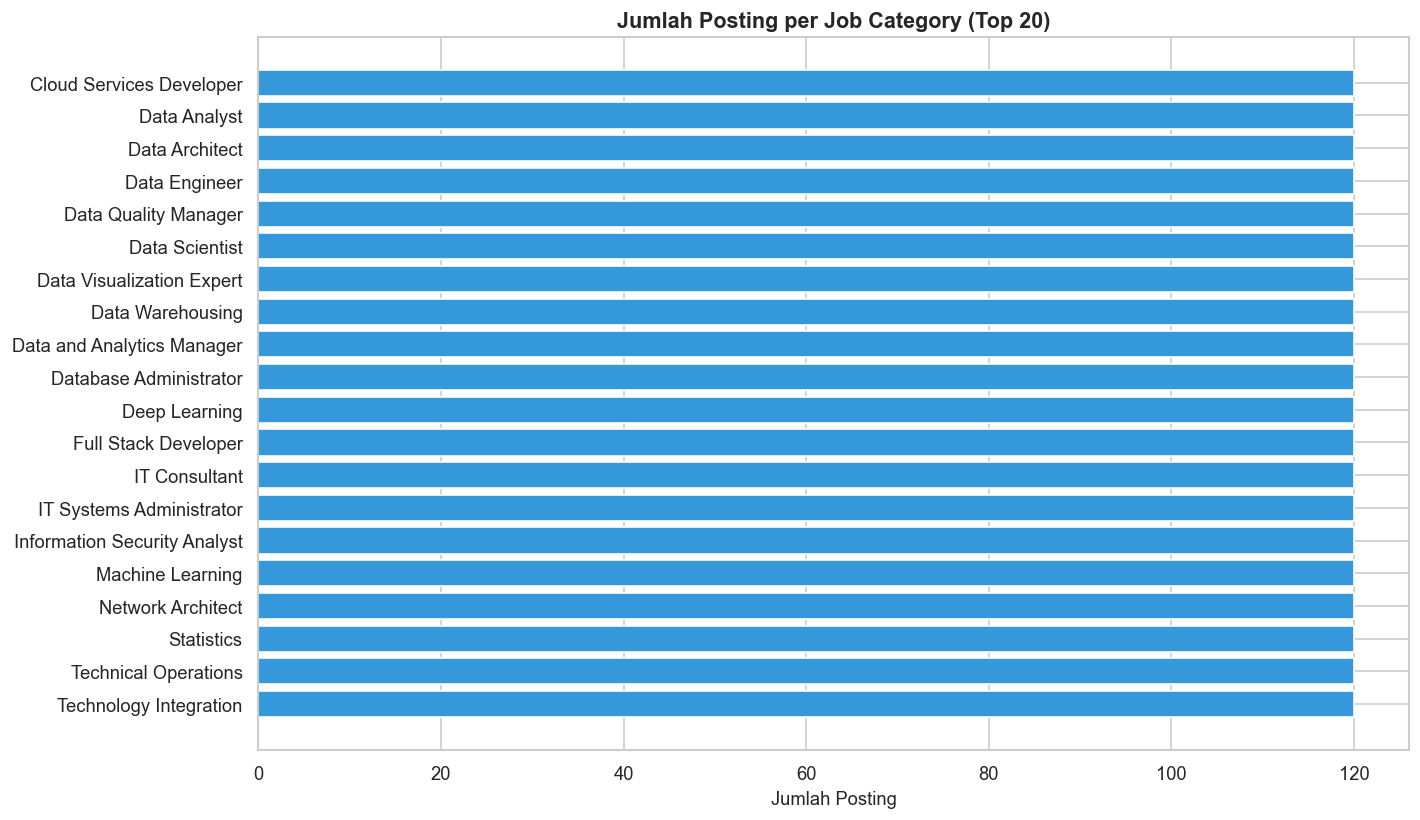

Total kategori pekerjaan: 25
Total posting          : 3,000


In [7]:
# === 2.4.1 Distribusi Jumlah Posting per Job Category ===
cat_counts = df_jobs['Query'].value_counts()
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(cat_counts.index[::-1][:20], cat_counts.values[::-1][:20],
        color='#3498db', edgecolor='white')
ax.set_xlabel('Jumlah Posting', fontsize=11)
ax.set_title('Jumlah Posting per Job Category (Top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total kategori pekerjaan: {df_jobs['Query'].nunique()}")
print(f"Total posting          : {len(df_jobs):,}")


#### 2.4.2 Distribusi Jumlah Skill yang Dibutuhkan per Job Category

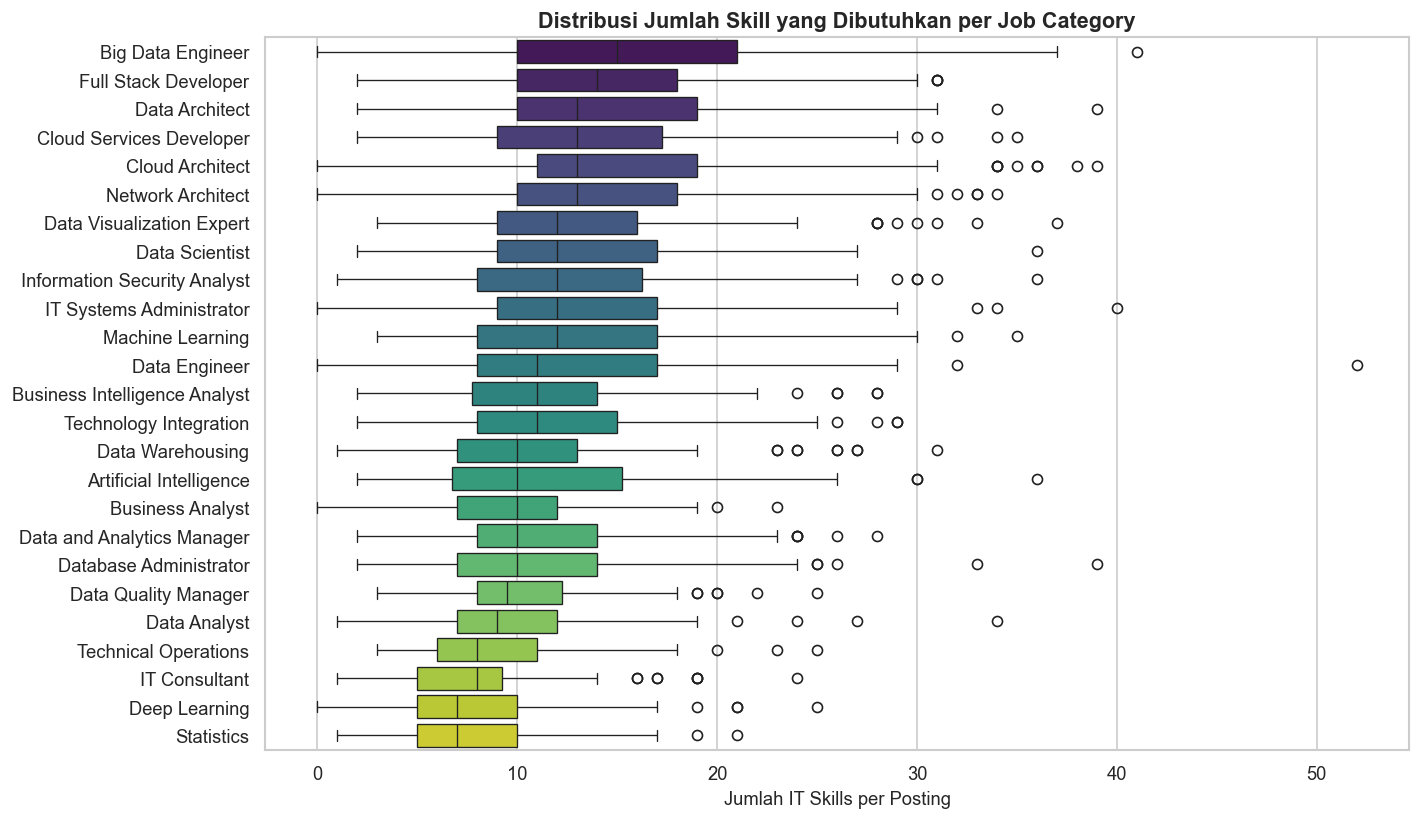

Rata-rata skill_count per job category:
  Big Data Engineer                  : mean=16.1, median=15, max=41
  Full Stack Developer               : mean=14.3, median=14, max=31
  Data Architect                     : mean=14.9, median=13, max=39
  Cloud Services Developer           : mean=14.1, median=13, max=35
  Cloud Architect                    : mean=15.9, median=13, max=39
  Network Architect                  : mean=14.8, median=13, max=34
  Data Visualization Expert          : mean=13.5, median=12, max=37
  Data Scientist                     : mean=12.6, median=12, max=36
  Information Security Analyst       : mean=13.2, median=12, max=36
  IT Systems Administrator           : mean=13.8, median=12, max=40
  Machine Learning                   : mean=13.6, median=12, max=35
  Data Engineer                      : mean=13.0, median=11, max=52
  Business Intelligence Analyst      : mean=11.3, median=11, max=28
  Technology Integration             : mean=12.0, median=11, max=29
  Data W

In [8]:
# Distribusi skill_count per job category
fig, ax = plt.subplots(figsize=(12, 7))
order = df_jobs.groupby('Query')['skill_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df_jobs, y='Query', x='skill_count', order=order, ax=ax,
            palette='viridis', linewidth=0.8)
ax.set_xlabel('Jumlah IT Skills per Posting', fontsize=11)
ax.set_ylabel('')
ax.set_title('Distribusi Jumlah Skill yang Dibutuhkan per Job Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ringkasan statistik
print("Rata-rata skill_count per job category:")
for cat in order:
    subset = df_jobs[df_jobs['Query'] == cat]['skill_count']
    print(f"  {cat:35s}: mean={subset.mean():.1f}, median={subset.median():.0f}, max={subset.max()}")

#### 2.4.3 Heatmap Skill Overlap antar Job Category

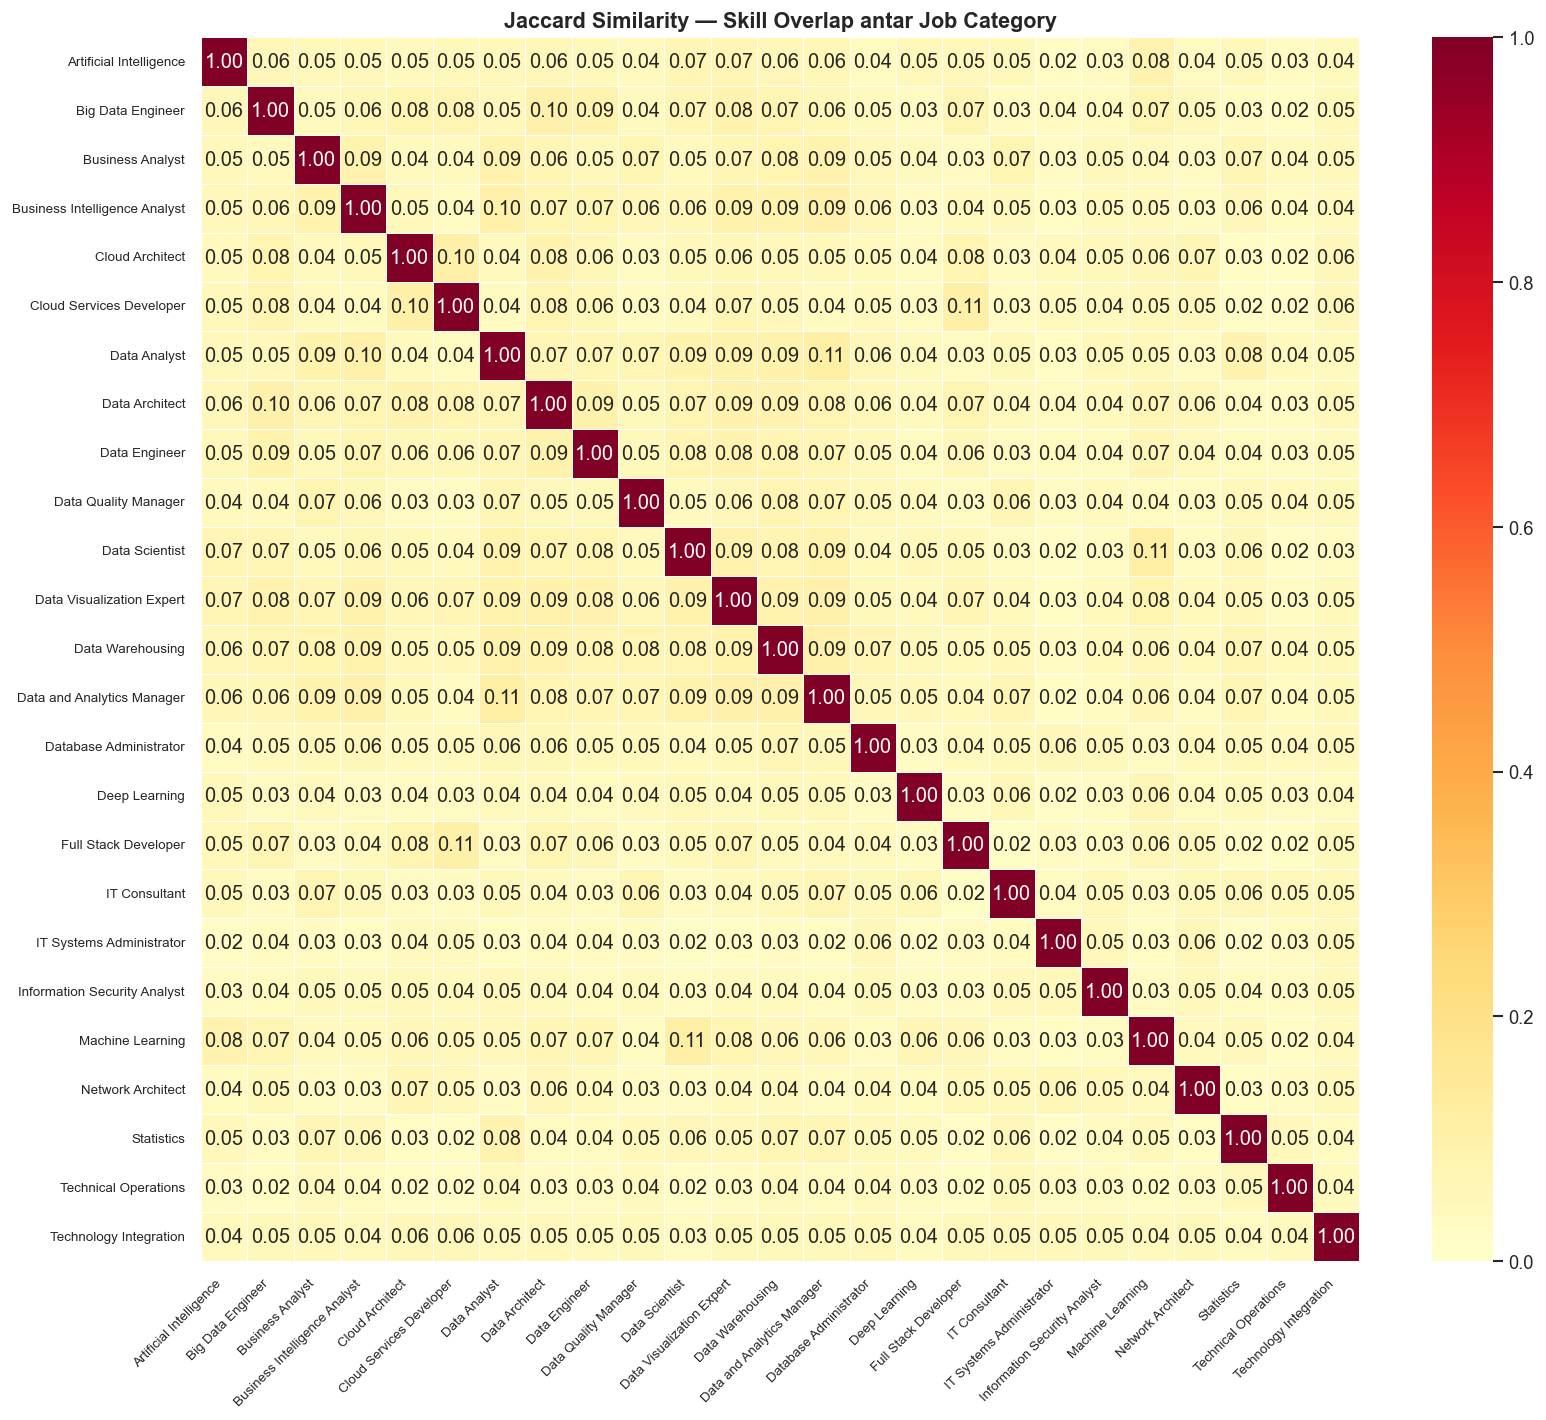


Top 5 Pasangan Job Category yang Paling Overlap:
  Data Analyst                   ↔ Data and Analytics Manager     : Jaccard=0.112
  Data Scientist                 ↔ Machine Learning               : Jaccard=0.110
  Cloud Services Developer       ↔ Full Stack Developer           : Jaccard=0.108
  Cloud Architect                ↔ Cloud Services Developer       : Jaccard=0.103
  Business Intelligence Analyst  ↔ Data Analyst                   : Jaccard=0.100


In [9]:
# Bangun heatmap overlap skill antar job category
cat_skill_sets = {}
for cat in df_jobs['Query'].unique():
    subset = df_jobs[df_jobs['Query'] == cat]
    skills_set = set()
    for skills in subset['IT Skills'].dropna():
        for s in str(skills).split(','):
            cleaned = s.strip().lower()
            if cleaned:
                skills_set.add(cleaned)
    cat_skill_sets[cat] = skills_set

# Jaccard similarity
categories = sorted(cat_skill_sets.keys())
n = len(categories)
sim_matrix = np.zeros((n, n))
for i, c1 in enumerate(categories):
    for j, c2 in enumerate(categories):
        s1, s2 = cat_skill_sets[c1], cat_skill_sets[c2]
        if len(s1 | s2) > 0:
            sim_matrix[i][j] = len(s1 & s2) / len(s1 | s2)
        else:
            sim_matrix[i][j] = 0

sim_df = pd.DataFrame(sim_matrix, index=categories, columns=categories)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=1,
            xticklabels=True, yticklabels=True)
ax.set_title('Jaccard Similarity — Skill Overlap antar Job Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Top 5 pasangan kategori yang paling overlap
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((categories[i], categories[j], sim_matrix[i][j]))
pairs.sort(key=lambda x: -x[2])
print("\nTop 5 Pasangan Job Category yang Paling Overlap:")
for c1, c2, sim in pairs[:5]:
    print(f"  {c1:30s} ↔ {c2:30s} : Jaccard={sim:.3f}")

#### 2.4.4 Analisis IT Skills dari Dataset Lowongan Kerja

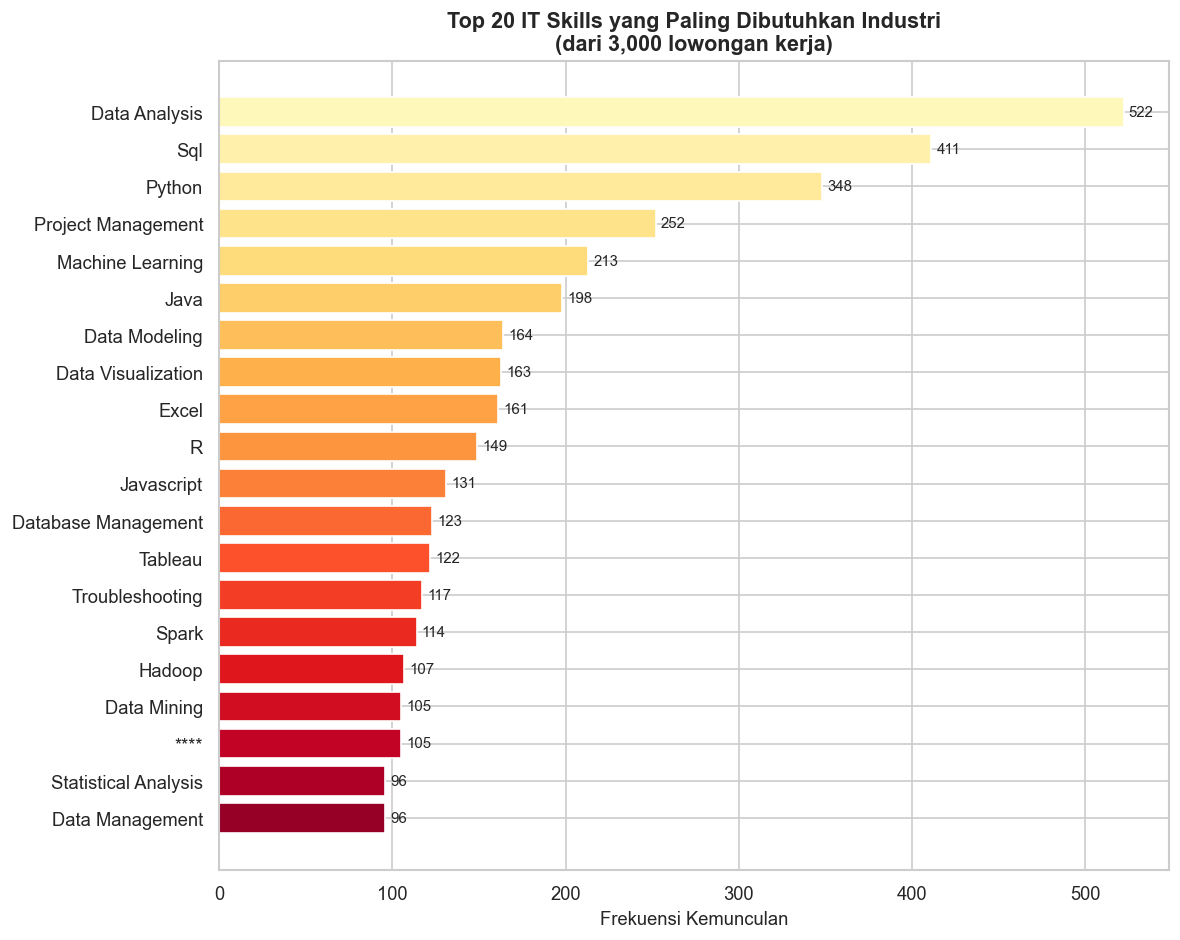

Total entri IT Skills  : 36,154
IT Skills unik         : 17,867


In [10]:
# Ekstrak dan hitung frekuensi IT Skills dari dataset lowongan kerja
all_it_skills = []
for skills in df_jobs['IT Skills'].dropna():
    for s in str(skills).split(','):
        cleaned = s.strip()
        if cleaned:
            all_it_skills.append(cleaned)

it_skill_counts = pd.Series(Counter(all_it_skills))
# Normalisasi case (gabungkan 'Data analysis' dan 'Data Analysis')
normalized = defaultdict(int)
for skill, cnt in it_skill_counts.items():
    normalized[skill.strip().title()] += cnt
it_skill_counts = pd.Series(normalized).sort_values(ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
top_skills = it_skill_counts.head(top_n)
bars = ax.barh(top_skills.index[::-1], top_skills.values[::-1],
               color=sns.color_palette('YlOrRd_r', top_n), edgecolor='white')
for bar, val in zip(bars, top_skills.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=9)
ax.set_xlabel('Frekuensi Kemunculan', fontsize=11)
ax.set_title(f'Top {top_n} IT Skills yang Paling Dibutuhkan Industri\n(dari {len(df_jobs):,} lowongan kerja)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total entri IT Skills  : {len(all_it_skills):,}")
print(f"IT Skills unik         : {len(it_skill_counts):,}")

#### 2.4.5 Analisis Soft Skills dari Dataset Lowongan Kerja

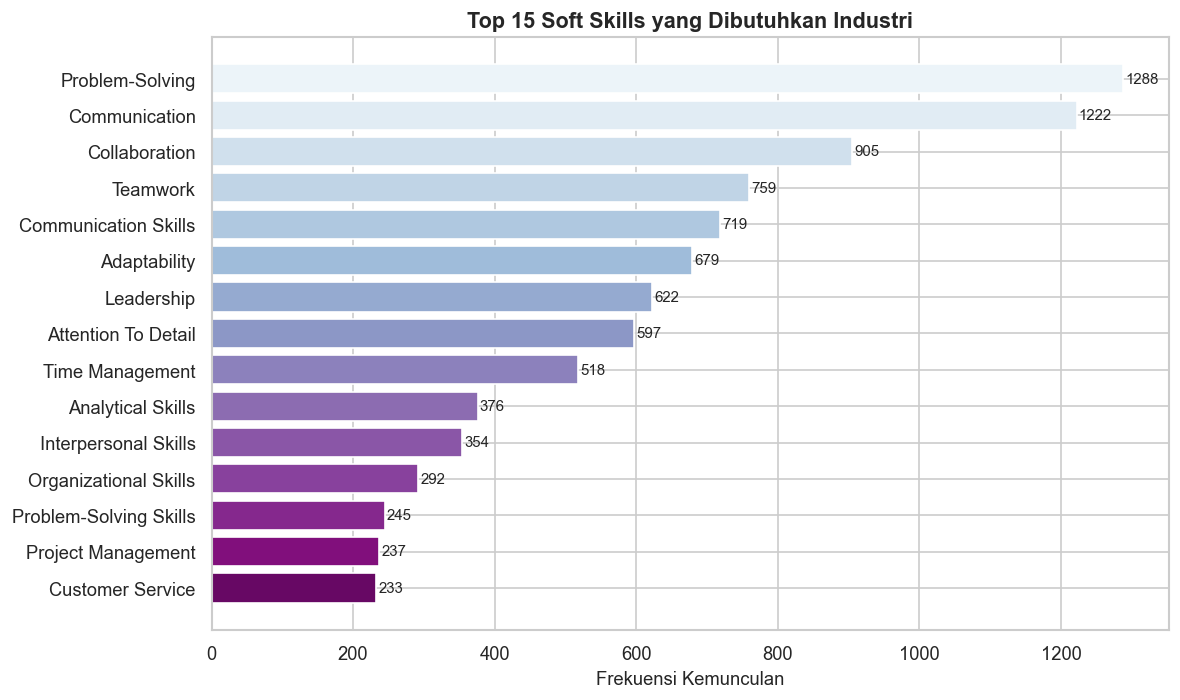

In [11]:
# Ekstrak soft skills
all_soft_skills = []
for skills in df_jobs['Soft Skills'].dropna():
    for s in str(skills).split(','):
        cleaned = s.strip()
        if cleaned:
            all_soft_skills.append(cleaned)

soft_skill_counts = pd.Series(Counter(all_soft_skills))
normalized_soft = defaultdict(int)
for skill, cnt in soft_skill_counts.items():
    normalized_soft[skill.strip().title()] += cnt
soft_skill_counts = pd.Series(normalized_soft).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_soft = soft_skill_counts.head(15)
bars = ax.barh(top_soft.index[::-1], top_soft.values[::-1],
               color=sns.color_palette('BuPu_r', 15), edgecolor='white')
for bar, val in zip(bars, top_soft.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)
ax.set_xlabel('Frekuensi Kemunculan', fontsize=11)
ax.set_title('Top 15 Soft Skills yang Dibutuhkan Industri', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.4.6 IT Skills per Kategori Pekerjaan

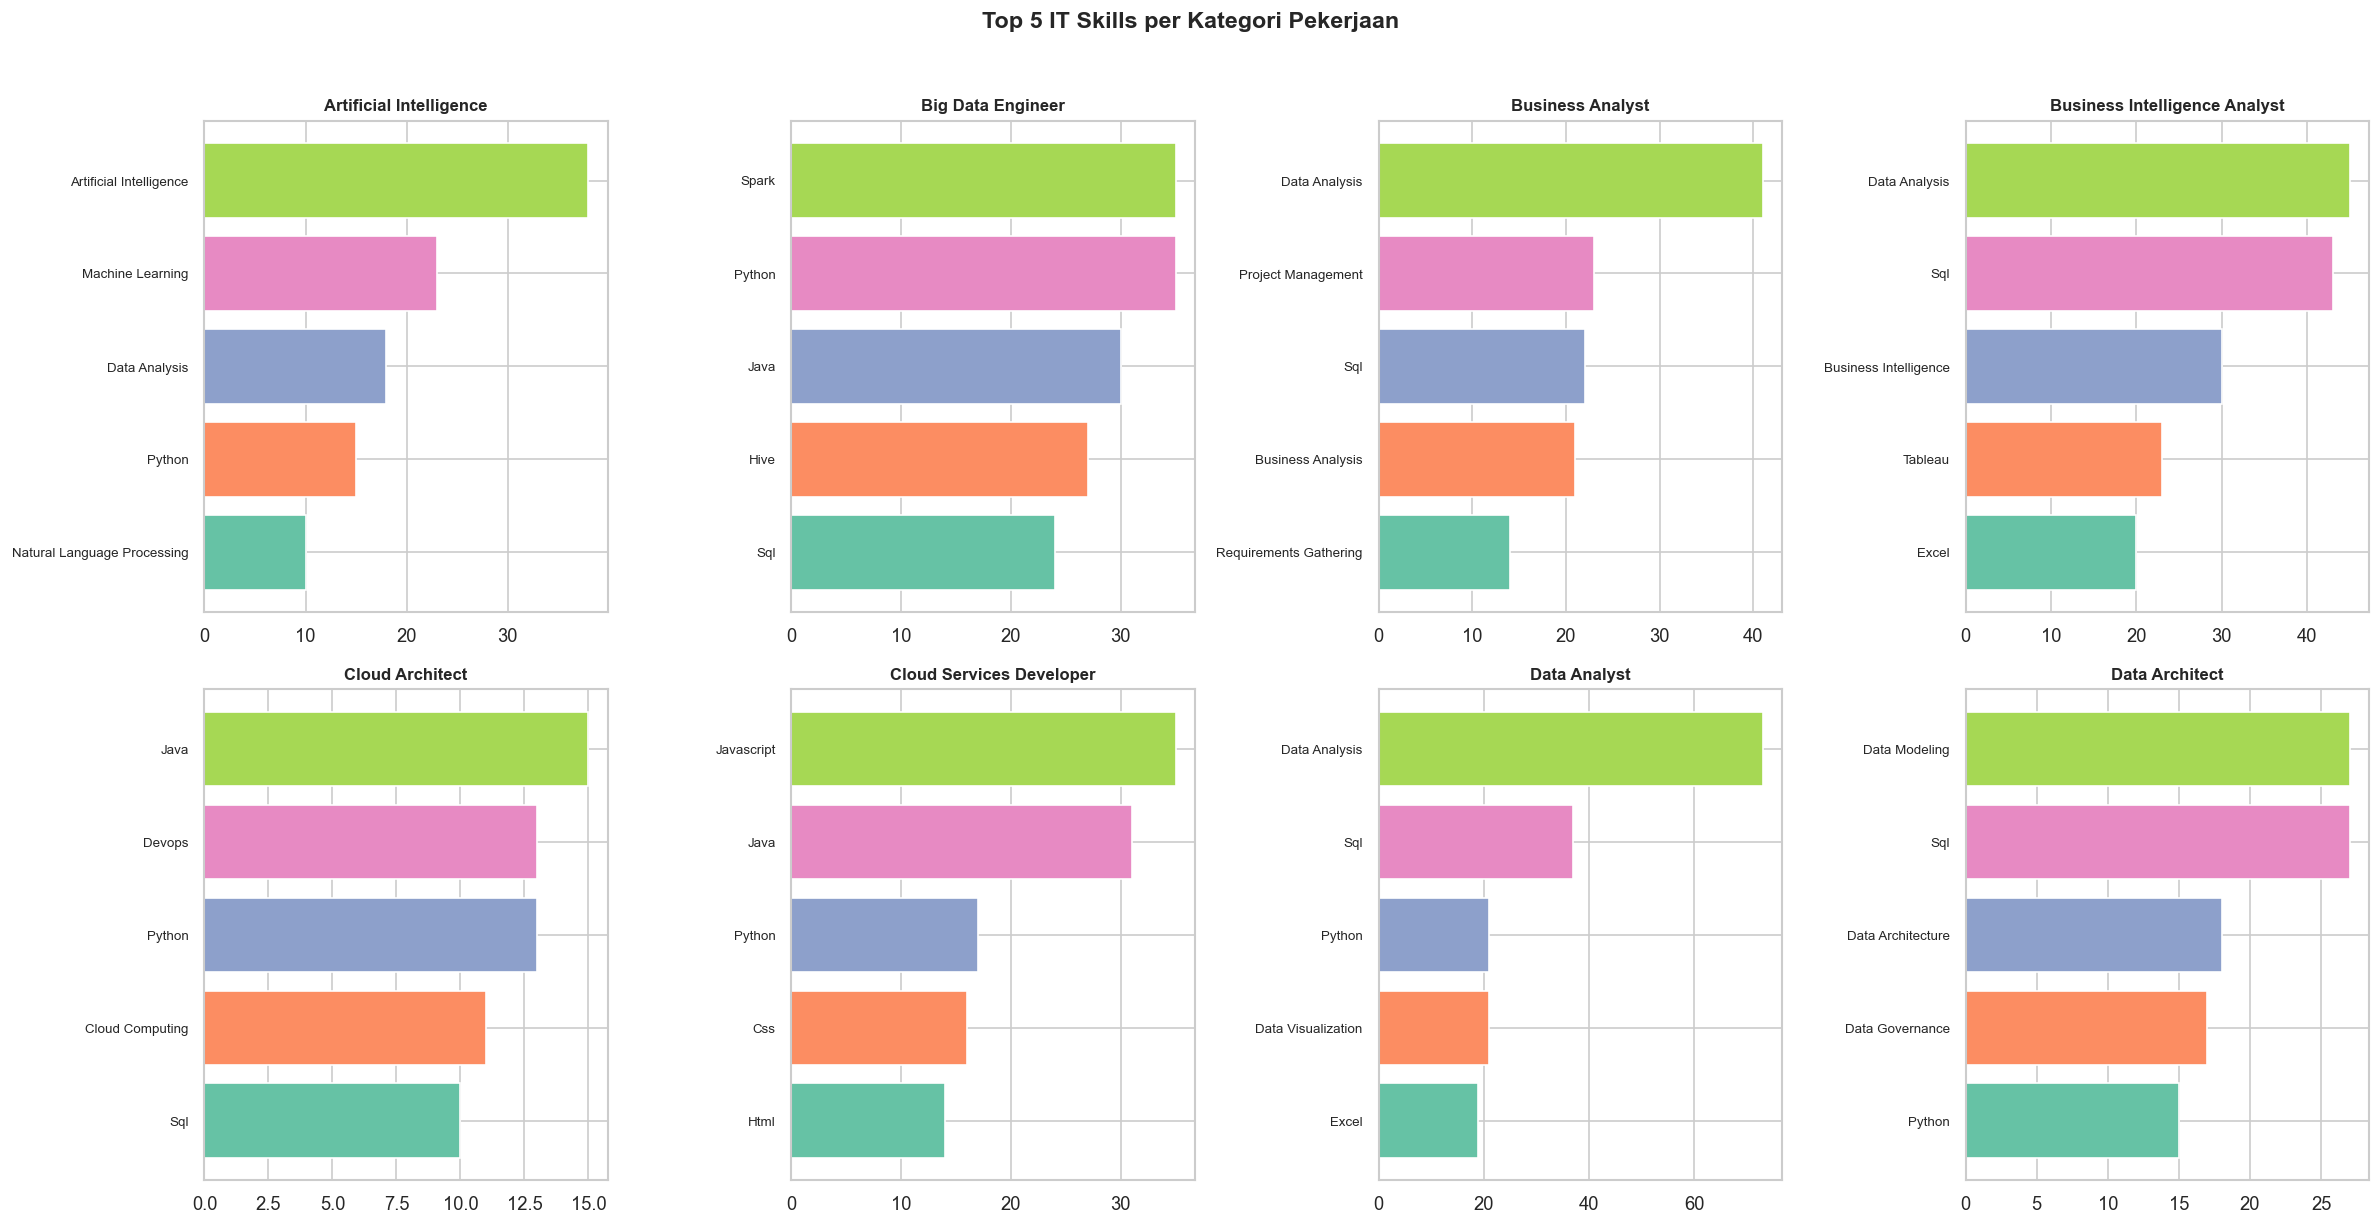

In [12]:
# Top 5 IT skills per kategori pekerjaan (Query)
categories = df_jobs['Query'].value_counts().head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, cat in enumerate(categories):
    subset = df_jobs[df_jobs['Query'] == cat]
    cat_skills = []
    for skills in subset['IT Skills'].dropna():
        for s in str(skills).split(','):
            cleaned = s.strip().title()
            if cleaned:
                cat_skills.append(cleaned)
    top5 = pd.Series(Counter(cat_skills)).sort_values(ascending=False).head(5)

    axes[idx].barh(top5.index[::-1], top5.values[::-1],
                   color=sns.color_palette('Set2', 5), edgecolor='white')
    axes[idx].set_title(cat, fontsize=10, fontweight='bold')
    axes[idx].tick_params(axis='y', labelsize=8)

fig.suptitle('Top 5 IT Skills per Kategori Pekerjaan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 2.4.7 Distribusi Tag NER

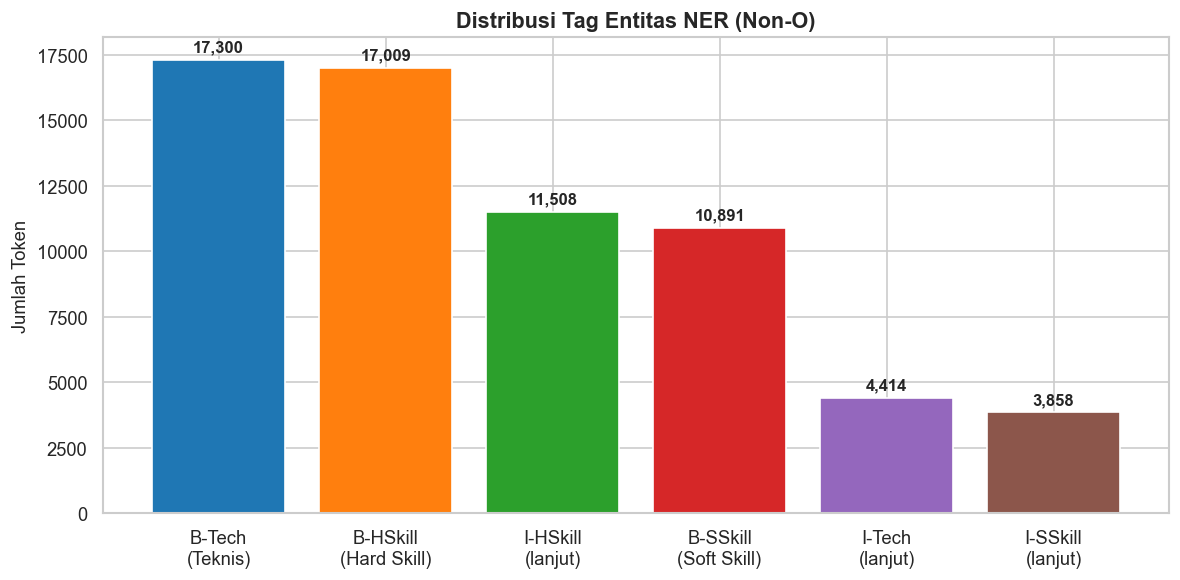


Ringkasan Tag Entitas:
          Jumlah Token  Persen
Tag                           
B-Tech           17300   4.130
B-HSkill         17009   4.061
I-HSkill         11508   2.747
B-SSkill         10891   2.600
I-Tech            4414   1.054
I-SSkill          3858   0.921


In [13]:
entity_tags = df_ner[df_ner['Tag'] != 'O']['Tag'].value_counts()
tag_labels = {
    'B-HSkill': 'B-HSkill\n(Hard Skill)', 'I-HSkill': 'I-HSkill\n(lanjut)',
    'B-Tech': 'B-Tech\n(Teknis)', 'I-Tech': 'I-Tech\n(lanjut)',
    'B-SSkill': 'B-SSkill\n(Soft Skill)', 'I-SSkill': 'I-SSkill\n(lanjut)',
}
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('tab10', len(entity_tags))
bars = ax.bar([tag_labels.get(t, t) for t in entity_tags.index], entity_tags.values, color=colors, edgecolor='white')
for bar, val in zip(bars, entity_tags.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Jumlah Token', fontsize=11)
ax.set_title('Distribusi Tag Entitas NER (Non-O)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

summary_ner = pd.DataFrame({'Jumlah Token': entity_tags.values,
    'Persen': (entity_tags.values / len(df_ner) * 100).round(3)}, index=entity_tags.index)
summary_ner.index.name = 'Tag'
print("\nRingkasan Tag Entitas:")
print(summary_ner)

---
### 2.5 Ringkasan Temuan Data Understanding

In [14]:
summary = pd.DataFrame([
    {'Dataset': 'IT Skills from Jobs', 'Jumlah Baris': f"{df_jobs.shape[0]:,}",
     'Jumlah Kolom': df_jobs.shape[1], 'Missing Values': int(df_jobs.isnull().sum().sum()),
     'Fitur Utama': 'IT Skills, Soft Skills, Job Title, Description'},
    {'Dataset': 'NER Skill Annotation', 'Jumlah Baris': f"{df_ner.shape[0]:,}",
     'Jumlah Kolom': df_ner.shape[1], 'Missing Values': int(df_ner.isnull().sum().sum()),
     'Fitur Utama': 'Word, Tag (B/I-HSkill, B/I-Tech, B/I-SSkill)'}
])
print("RINGKASAN DATASET")
print("=" * 90)
print(summary.set_index('Dataset').to_string())

print("\n\nTEMUAN UTAMA:")
print("=" * 90)
print(f"1. Terdapat {df_jobs['Query'].nunique()} kategori pekerjaan IT dengan {len(df_jobs):,} posting")
print(f"2. Rata-rata skill per posting: {df_jobs['skill_count'].mean():.1f} (median {df_jobs['skill_count'].median():.0f})")
print(f"3. Total nilai skill unik pada kolom IT Skills: {df_jobs['IT Skills'].dropna().apply(lambda s: len(set(str(s).split(',')))).sum():,} entri")
print(f"4. Missing value tinggi pada Education ({df_jobs['Education'].eq('').sum()}) dan Experience ({df_jobs['Experience'].eq('').sum()})")
print(f"5. Dataset NER memiliki {df_ner.shape[0]:,} token dengan {df_ner[df_ner['Tag'] != 'O'].shape[0]:,} entitas skill")


RINGKASAN DATASET
                     Jumlah Baris  Jumlah Kolom  Missing Values                                     Fitur Utama
Dataset                                                                                                        
IT Skills from Jobs         3,000            10              32  IT Skills, Soft Skills, Job Title, Description
NER Skill Annotation      418,868             3          414567    Word, Tag (B/I-HSkill, B/I-Tech, B/I-SSkill)


TEMUAN UTAMA:
1. Terdapat 25 kategori pekerjaan IT dengan 3,000 posting
2. Rata-rata skill per posting: 12.1 (median 11)
3. Total nilai skill unik pada kolom IT Skills: 36,093 entri
4. Missing value tinggi pada Education (1437) dan Experience (1428)
5. Dataset NER memiliki 418,868 token dengan 64,980 entitas skill


---
## TAHAP 3 — DATA PREPARATION

Pada tahap ini dilakukan persiapan data untuk membangun **model prediksi skill multi-label**:
- Normalisasi skill (BAB 3.1)
- Skill vocabulary dari NER & data industri (BAB 3.2)
- Kandidat skill target sebagai label space multi-label (BAB 3.3)
- Dataset multi-label + simulasi konteks agar skill user menjadi input model (BAB 3.4)


---
### 3.1 Pembersihan dan Normalisasi Data

In [15]:
# === 3.1 Normalisasi dan Pembersihan ===
print("=" * 60)
print("  PEMBERSIHAN DAN NORMALISASI DATA")
print("=" * 60)

# (a) Normalisasi IT Skills (lowercase, strip whitespace, deduplication)
def normalize_skills(skill_str):
    if pd.isna(skill_str):
        return ''
    skills = [s.strip().lower() for s in str(skill_str).split(',') if s.strip()]
    # Deduplikasi sambil menjaga urutan
    seen = set()
    unique = []
    for s in skills:
        if s not in seen:
            seen.add(s)
            unique.append(s)
    return ', '.join(unique)

df_jobs['IT_Skills_Clean'] = df_jobs['IT Skills'].apply(normalize_skills)
print("(a) Normalisasi IT Skills selesai")
print(f"    Contoh sebelum: {df_jobs['IT Skills'].iloc[0][:100]}...")
print(f"    Contoh sesudah: {df_jobs['IT_Skills_Clean'].iloc[0][:100]}...")

# (b) Missing value Education & Experience sudah ditangani di BAB 2.3
print(f"\n(b) Missing value Education & Experience sudah ditangani di BAB 2.3")
print(f"\nShape akhir df_jobs: {df_jobs.shape}")
df_jobs[['Query', 'Job Title', 'IT_Skills_Clean', 'skill_count', 'Description']].head()


  PEMBERSIHAN DAN NORMALISASI DATA
(a) Normalisasi IT Skills selesai
    Contoh sebelum: Collaborative Manipulation, Artificial Intelligence, Robot Operating System (ROS), Programming (Pyth...
    Contoh sesudah: collaborative manipulation, artificial intelligence, robot operating system (ros), programming (pyth...

(b) Missing value Education & Experience sudah ditangani di BAB 2.3

Shape akhir df_jobs: (3000, 11)


,Query,Job Title,IT_Skills_Clean,skill_count,Description
0,Artificial Intelligence,Collaborative Manipulation Roboticist,"collaborative manipulation, artificial intelligence, robot operating system ...",10,"Location: Schlumberger-Doll Research, Cambridge, MA, USA At Schlumberger-Dol..."
1,Artificial Intelligence,Software Engineer - Innovation Lab,"software development, infotainment systems, augmented reality (ar), heads-up...",17,About DENSO DENSO is one of the largest global automotive suppliers of advan...
2,Artificial Intelligence,"Director, Standards & Strategy","audio/video codec, media streaming and storage formats, ar/vr, machine learn...",6,"As a Director of Strategy & Strategy at Xperi, you will participate in indus..."
3,Artificial Intelligence,Business Strategy Consultant,"mobility technological trends expertise, business strategy development, auto...",13,If you have a strategic mindset and expertise in the latest mobility technol...
4,Artificial Intelligence,Regular Full-Time,"test planning, bug tracking tools, automation principles, writing test cases...",9,Mission Who We Are Founded and continuously led by inventor and entrepreneur...


---
### 3.2 Bangun Skill Vocabulary dari NER & Data Industri

In [16]:
# ─── 3.2a Skill Vocabulary dari NER ───────────────────────────────────────
skill_vocab = defaultdict(set)
current_entity = None
current_words = []

for _, row in df_ner.iterrows():
    tag = row['Tag']
    word = str(row['Word'])
    if tag.startswith('B-'):
        if current_entity and current_words:
            skill_vocab[current_entity].add(' '.join(current_words))
        current_entity = tag[2:]
        current_words = [word]
    elif tag.startswith('I-') and current_entity == tag[2:]:
        current_words.append(word)
    else:
        if current_entity and current_words:
            skill_vocab[current_entity].add(' '.join(current_words))
        current_entity = None
        current_words = []
if current_entity and current_words:
    skill_vocab[current_entity].add(' '.join(current_words))

print("=" * 60)
print("  SKILL VOCABULARY DARI NER")
print("=" * 60)
for category, skills in skill_vocab.items():
    print(f"\n{category} ({len(skills)} skill unik):")
    for s in sorted(skills)[:8]:
        print(f"  - {s}")
    if len(skills) > 8:
        print(f"  ... dan {len(skills)-8} lainnya")

# ─── 3.2b Skill Vocabulary dari IT Skills from Jobs ──────────────────────
industry_it_skills = defaultdict(int)
industry_soft_skills = defaultdict(int)

for _, row in df_jobs.iterrows():
    query = row['Query']
    if pd.notna(row['IT Skills']):
        for s in str(row['IT Skills']).split(','):
            cleaned = s.strip()
            if cleaned:
                industry_it_skills[cleaned] += 1
    if pd.notna(row['Soft Skills']):
        for s in str(row['Soft Skills']).split(','):
            cleaned = s.strip()
            if cleaned:
                industry_soft_skills[cleaned] += 1

# Buat mapping skill per kategori pekerjaan
job_category_skills = defaultdict(lambda: defaultdict(int))
for _, row in df_jobs.iterrows():
    query = row['Query']
    if pd.notna(row['IT Skills']):
        for s in str(row['IT Skills']).split(','):
            cleaned = s.strip()
            if cleaned:
                job_category_skills[query][cleaned] += 1

print("\n" + "=" * 60)
print("  SKILL VOCABULARY DARI DATA INDUSTRI")
print("=" * 60)
print(f"\nTotal IT Skills unik  : {len(industry_it_skills):,}")
print(f"Total Soft Skills unik: {len(industry_soft_skills):,}")
print(f"Kategori pekerjaan    : {len(job_category_skills)}")
print(f"\nTop 10 IT Skills industri:")
for skill, cnt in sorted(industry_it_skills.items(), key=lambda x: -x[1])[:10]:
    print(f"  {skill:40s}: {cnt}")

# ─── 3.2c Mapping Skill ke Subdomain (Referensi SKKNI/SFIA) ─────────────
skill_subdomain = {
    'Software Development': [
        'python', 'java', 'javascript', 'c++', 'c#', 'ruby', 'php', 'go',
        'react', 'angular', 'node.js', 'django', 'flask', 'spring',
        'html', 'css', 'git', 'agile', 'scrum', 'devops', 'ci/cd',
        'rest api', 'microservices', 'docker', 'kubernetes',
        'software development', 'full stack', 'frontend', 'backend',
        'mobile development', 'ios', 'android', 'swift', 'kotlin',
    ],
    'Data Engineering': [
        'sql', 'python', 'spark', 'hadoop', 'kafka', 'airflow',
        'etl', 'data pipeline', 'data warehouse', 'data lake',
        'big data', 'nosql', 'mongodb', 'postgresql', 'mysql',
        'data modeling', 'data architecture', 'data governance',
        'machine learning', 'deep learning', 'tensorflow', 'pytorch',
        'data analysis', 'data visualization', 'tableau', 'power bi',
        'statistics', 'r', 'pandas', 'numpy', 'scikit-learn',
    ],
    'Cybersecurity': [
        'cybersecurity', 'information security', 'network security',
        'penetration testing', 'vulnerability assessment', 'siem',
        'firewall', 'ids/ips', 'encryption', 'cryptography',
        'incident response', 'security audit', 'compliance',
        'iso 27001', 'nist', 'gdpr', 'soc', 'risk management',
        'malware analysis', 'forensics', 'ethical hacking',
    ],
    'Cloud Computing': [
        'aws', 'azure', 'gcp', 'google cloud', 'cloud computing',
        'cloud architecture', 'serverless', 'lambda', 'ec2', 's3',
        'terraform', 'ansible', 'infrastructure as code',
        'cloud security', 'cloud migration', 'saas', 'paas', 'iaas',
        'virtualization', 'vmware', 'openstack',
    ],
}

print("\n" + "=" * 60)
print("  MAPPING SKILL KE SUBDOMAIN (SKKNI/SFIA)")
print("=" * 60)
for domain, skills in skill_subdomain.items():
    print(f"\n{domain} ({len(skills)} referensi skill):")
    print(f"  {', '.join(skills[:10])}{'...' if len(skills) > 10 else ''}")

  SKILL VOCABULARY DARI NER

HSkill (5638 skill unik):
  - .Net Developer
  - .Program
  - .Teaching
  - .net Developer
  - /pengembangan API
  - AD/LDAP security
  - AGILE
  - ANALISIS SISTEM
  ... dan 5630 lainnya

Tech (3319 skill unik):
  - ,
  - .Cisco CCNA/CCNP
  - .NET
  - .NET Core
  - .NET Core Framework
  - .NET Framework
  - .NET MVC
  - .NET WinForm
  ... dan 3311 lainnya

SSkill (1320 skill unik):
  - ,
  - .Bahasa Inggris
  - .Jujur
  - .Komunikasi
  - .Kreatif
  - .Proaktif
  - 1
  - Adaptable
  ... dan 1312 lainnya

  SKILL VOCABULARY DARI DATA INDUSTRI

Total IT Skills unik  : 19,487
Total Soft Skills unik: 4,119
Kategori pekerjaan    : 25

Top 10 IT Skills industri:
  SQL                                     : 411
  Data analysis                           : 356
  Python                                  : 347
  Java                                    : 192
  Data Analysis                           : 165
  Excel                                   : 161
  R                

---
### 3.3 Kandidat Skill Target — Label Space Multi-Label

Model baru memprediksi **skill yang dibutuhkan** secara multi-label (bukan seniority level). Label space dibatasi pada **top-N skill paling sering muncul** agar pelatihan multi-label tetap tractable.


In [17]:
# === 3.3 Kandidat Skill Target (Multi-Label) ===
from collections import Counter
import numpy as np

MIN_FREQ = 5
N_SKILLS = 150

skill_counter = Counter()
for skills in df_jobs['IT_Skills_Clean']:
    for sk in str(skills).split(', '):
        if sk:
            skill_counter[sk] += 1

candidate_skills = [s for s, n in skill_counter.items() if n >= MIN_FREQ]
candidate_skills.sort(key=lambda s: -skill_counter[s])
candidate_skills = candidate_skills[:N_SKILLS]
candidate_skills.sort()


def skill_set(s):
    return {x for x in str(s).split(', ') if x} if pd.notna(s) else set()


df_jobs['skill_set'] = df_jobs['IT_Skills_Clean'].apply(skill_set)

label_matrix = np.zeros((len(df_jobs), len(candidate_skills)))
for i, sset in enumerate(df_jobs['skill_set']):
    for j, c in enumerate(candidate_skills):
        if c in sset:
            label_matrix[i, j] = 1

print("=" * 65)
print("  KANDIDAT SKILL TARGET (LABEL SPACE)")
print("=" * 65)
print(f"  Total skill unik di dataset : {len(skill_counter):,}")
print(f"  Min frekuensi               : {MIN_FREQ}")
print(f"  Kandidat skill digunakan    : {len(candidate_skills)}")
print(f"  Ukuran label matrix         : {label_matrix.shape}")
print(f"  Rata-rata label aktif/baris : {label_matrix.sum(axis=1).mean():.2f}")
print(f"  Posting tanpa kandidat      : {(label_matrix.sum(axis=1) == 0).sum()}")


  KANDIDAT SKILL TARGET (LABEL SPACE)
  Total skill unik di dataset : 17,867
  Min frekuensi               : 5
  Kandidat skill digunakan    : 150
  Ukuran label matrix         : (3000, 150)
  Rata-rata label aktif/baris : 2.97
  Posting tanpa kandidat      : 590


---
### 3.4 Dataset Multi-Label & Simulasi Konteks

Agar "skill yang dimiliki user" benar-benar menjadi **input model**, setiap posting menghasilkan beberapa instance pelatihan:
1. **Konteks kosong (∅)** — benchmark skill untuk kategori secara murni
2. **Subset acak** dari skill posting — mensimulasikan user yang sudah menguasai sebagian skill

Fitur: **TF-IDF skill yang dimiliki user** (vocabulary = kandidat skill) + **one-hot kategori pekerjaan**. Label: vektor biner skill yang dibutuhkan pada posting tersebut.


In [18]:
# === 3.4 Dataset Multi-Label + Simulasi Konteks ===
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix


def skill_tokenizer(text):
    return [s.strip() for s in str(text).split(',') if s.strip()]


categories_sorted = sorted(df_jobs['Query'].unique())
cat_to_idx = {c: i for i, c in enumerate(categories_sorted)}
N_CAT = len(categories_sorted)


def onehot(idx, n):
    v = np.zeros(n); v[idx] = 1.0; return v


rng = np.random.RandomState(42)


def build_instances(idx_list, n_ctx=4):
    inst_idx, inst_ctx, inst_cat = [], [], []
    for i in idx_list:
        sset_list = sorted(df_jobs.at[i, 'skill_set'])
        cat = df_jobs.at[i, 'Query']
        inst_idx.append(i); inst_ctx.append(''); inst_cat.append(cat)
        for _ in range(n_ctx - 1):
            if not sset_list:
                inst_idx.append(i); inst_ctx.append(''); inst_cat.append(cat)
                continue
            k = rng.randint(1, len(sset_list) + 1)
            sub = sorted(rng.choice(sset_list, size=k, replace=False).tolist())
            inst_idx.append(i); inst_ctx.append(', '.join(sub)); inst_cat.append(cat)
    return inst_idx, inst_ctx, inst_cat


post_idx = np.arange(len(df_jobs))
tr_idx, te_idx = train_test_split(post_idx, test_size=0.20, random_state=42, shuffle=True)

tr_i, tr_ctx, tr_cat = build_instances(tr_idx)
te_i, te_ctx, te_cat = build_instances(te_idx)

tfidf_ctx = TfidfVectorizer(vocabulary=candidate_skills, tokenizer=skill_tokenizer)
X_tr_ctx = tfidf_ctx.fit_transform(tr_ctx)
X_te_ctx = tfidf_ctx.transform(te_ctx)

q_tr = np.array([onehot(cat_to_idx[c], N_CAT) for c in tr_cat])
q_te = np.array([onehot(cat_to_idx[c], N_CAT) for c in te_cat])

X_train = hstack([X_tr_ctx, csr_matrix(q_tr)]).tocsr()
X_test = hstack([X_te_ctx, csr_matrix(q_te)]).tocsr()
Y_train = label_matrix[tr_i]
Y_test = label_matrix[te_i]

bench_mask = np.array([ctx == '' for ctx in te_ctx], dtype=bool)
bench_idx = np.where(bench_mask)[0]

print("=" * 65)
print("  DATASET MULTI-LABEL (TRAIN/TEST)")
print("=" * 65)
print(f"  Fitur       : TF-IDF skill ({len(candidate_skills)}) + one-hot kategori ({N_CAT})")
print(f"  Total fitur : {X_train.shape[1]}")
print(f"  Label       : {Y_train.shape[1]} kandidat skill (binary multi-label)")
print(f"  Train       : {X_train.shape[0]:,} instance")
print(f"  Test        : {X_test.shape[0]:,} instance (benchmark murni: {sum(bench_mask)})")


  DATASET MULTI-LABEL (TRAIN/TEST)
  Fitur       : TF-IDF skill (150) + one-hot kategori (25)
  Total fitur : 175
  Label       : 150 kandidat skill (binary multi-label)
  Train       : 9,600 instance
  Test        : 2,400 instance (benchmark murni: 612)


---
## BAB 4 — MODELING

Model yang dibangun adalah **multi-label skill predictor** (binary relevance): setiap kandidat skill diperlakukan sebagai label biner, dan model memprediksi probabilitas suatu skill dibutuhkan untuk posisi target mengingat skill yang sudah dimiliki user.

Arsitektur yang dibandingkan:
1. **OneVsRest Logistic Regression** — baseline linear
2. **OneVsRest SGDClassifier** — linear berbasis SGD
3. **Random Forest multi-output** — non-linear, memprediksi seluruh label sekaligus


In [19]:
# === 4.1 Modeling Multi-Label (Binary Relevance) ===
import time
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

models = {}
print("=" * 70)
print("  MODELING MULTI-LABEL — PREDIKSI SKILL")
print("=" * 70)

t0 = time.time()
ovr_lr = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=2000, solver='liblinear'), n_jobs=-1)
ovr_lr.fit(X_train, Y_train)
models['OneVsRest Logistic Regression'] = ovr_lr
print(f"  [OK] OneVsRest LogisticRegression ({time.time()-t0:.1f}s)")

t0 = time.time()
ovr_sgd = OneVsRestClassifier(
    SGDClassifier(loss='log_loss', max_iter=2000, random_state=42), n_jobs=-1)
ovr_sgd.fit(X_train, Y_train)
models['OneVsRest SGDClassifier'] = ovr_sgd
print(f"  [OK] OneVsRest SGDClassifier ({time.time()-t0:.1f}s)")

t0 = time.time()
rf_multi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_multi.fit(X_train, Y_train)
models['Random Forest (Multi-Output)'] = rf_multi
print(f"  [OK] RandomForest Multi-Output ({time.time()-t0:.1f}s)")


  MODELING MULTI-LABEL — PREDIKSI SKILL
  [OK] OneVsRest LogisticRegression (7.5s)
  [OK] OneVsRest SGDClassifier (0.3s)
  [OK] RandomForest Multi-Output (26.0s)


---
### 4.2 Evaluasi Multi-Label — Precision/Recall @K

Metrik **top-K** relevan dengan aplikasi (benchmark top-N skill):
- **Precision@k** — proporsi skill prediksi top-k yang benar-benar dibutuhkan
- **Recall@k** — proporsi skill yang dibutuhkan yang tertangkap di top-k
- **F1@k** — harmonic mean keduanya
- **Hamming loss** — kesalahan klasifikasi per label


In [20]:
# === 4.2 Evaluasi Multi-Label (@K) ===
from sklearn.metrics import hamming_loss


def get_scores(model, X):
    p = model.predict_proba(X)
    if isinstance(p, list):
        p = np.asarray(p)
        p = np.transpose(p, (1, 0, 2))
        p = p[:, :, 1]
    elif p.ndim == 3:
        p = p[:, :, 1]
    return p


def topk_precision(Y_true, scores, k):
    preds = np.argsort(-scores, axis=1)[:, :k]
    vals = [Y_true[i][pidx].sum() / k for i, pidx in enumerate(preds)]
    return float(np.mean(vals))


def topk_recall(Y_true, scores, k):
    preds = np.argsort(-scores, axis=1)[:, :k]
    vals = []
    for i, pidx in enumerate(preds):
        denom = Y_true[i].sum()
        if denom > 0:
            vals.append(Y_true[i][pidx].sum() / denom)
    return float(np.mean(vals)) if vals else 0.0


KS = (5, 10, 15)
eval_rows = []
for name, model in models.items():
    sc = get_scores(model, X_test[bench_idx])
    yt = Y_test[bench_idx]
    row = {'Model': name}
    for k in KS:
        p = topk_precision(yt, sc, k)
        r = topk_recall(yt, sc, k)
        f = 2 * p * r / (p + r) if (p + r) else 0.0
        row[f'P@{k}'] = round(p, 4)
        row[f'R@{k}'] = round(r, 4)
        row[f'F1@{k}'] = round(f, 4)
    row['Hamming'] = round(hamming_loss(yt, (sc >= 0.5).astype(int)), 4)
    eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows).set_index('Model')
print("EVALUASI MULTI-LABEL (test set, konteks kosong):")
print(eval_df.to_string())


EVALUASI MULTI-LABEL (test set, konteks kosong):
                                  P@5     R@5    F1@5    P@10    R@10   F1@10    P@15    R@15   F1@15  Hamming
Model                                                                                                         
OneVsRest Logistic Regression  0.1621  0.3059  0.2119  0.1160  0.4340  0.1831  0.0949  0.5098  0.1600   0.0196
OneVsRest SGDClassifier        0.1598  0.3087  0.2106  0.1160  0.4257  0.1823  0.0930  0.5056  0.1571   0.0195
Random Forest (Multi-Output)   0.1627  0.3132  0.2142  0.1154  0.4344  0.1823  0.0935  0.5066  0.1578   0.0196


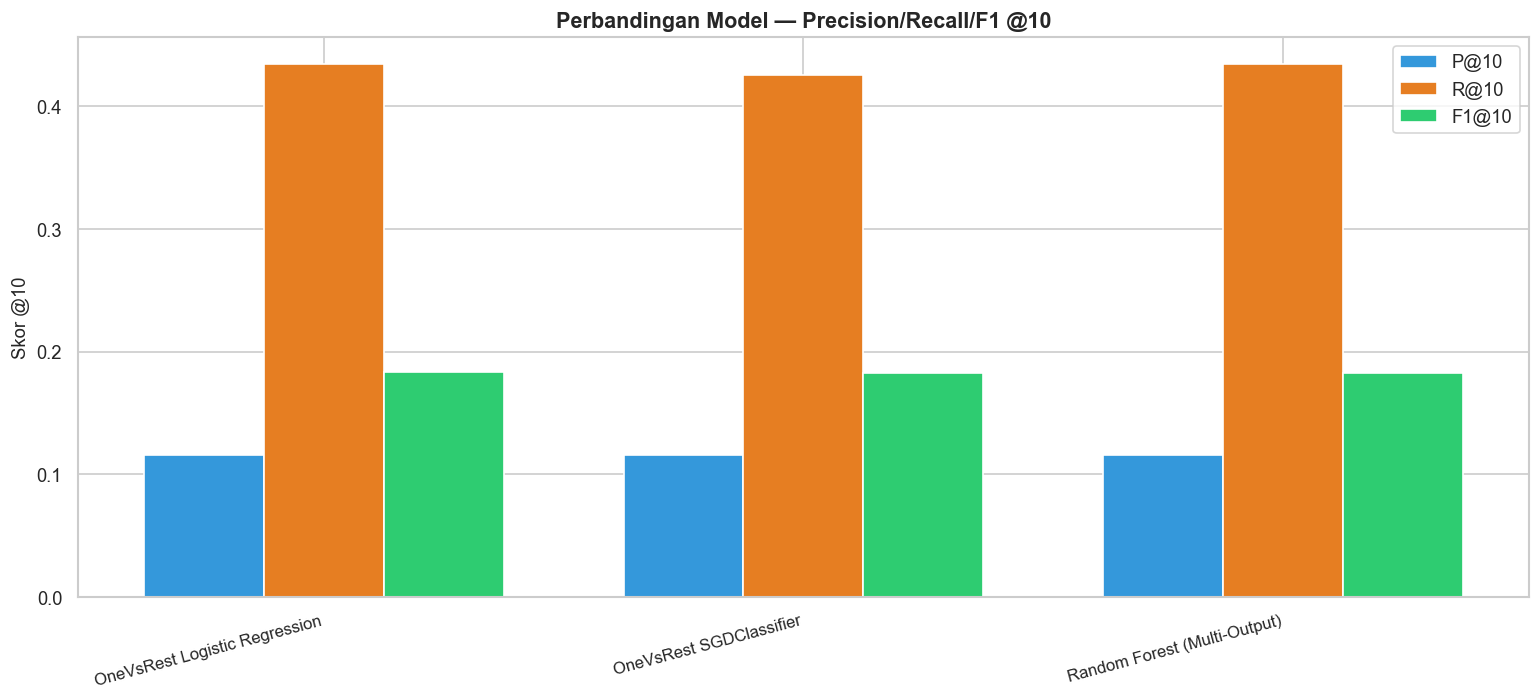

In [21]:
# === 4.2 Plot: Perbandingan Precision/Recall @10 ===
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(eval_df))
width = 0.25
colors = {'P@10': '#3498db', 'R@10': '#e67e22', 'F1@10': '#2ecc71'}
for i, (col, colr) in enumerate(colors.items()):
    ax.bar(x + (i - 1) * width, eval_df[col].values, width, label=col, color=colr, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(eval_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Skor @10', fontsize=11)
ax.set_title('Perbandingan Model — Precision/Recall/F1 @10', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('images/Perbandingan Precision-Recall Model.png', bbox_inches='tight')
plt.show()


PERBANDINGAN PERFORMA MODEL (threshold 0.1):
                               Micro-F1  Macro-F1  Samples-F1  Hamming Acc  Subset Acc   F1@10
Model                                                                                         
OneVsRest Logistic Regression  0.215763  0.050833    0.138982     0.971492    0.081699  0.1831
OneVsRest SGDClassifier        0.214363  0.056776    0.141630     0.968540    0.071895  0.1823
Random Forest (Multi-Output)   0.219092  0.064168    0.141640     0.964978    0.071895  0.1823


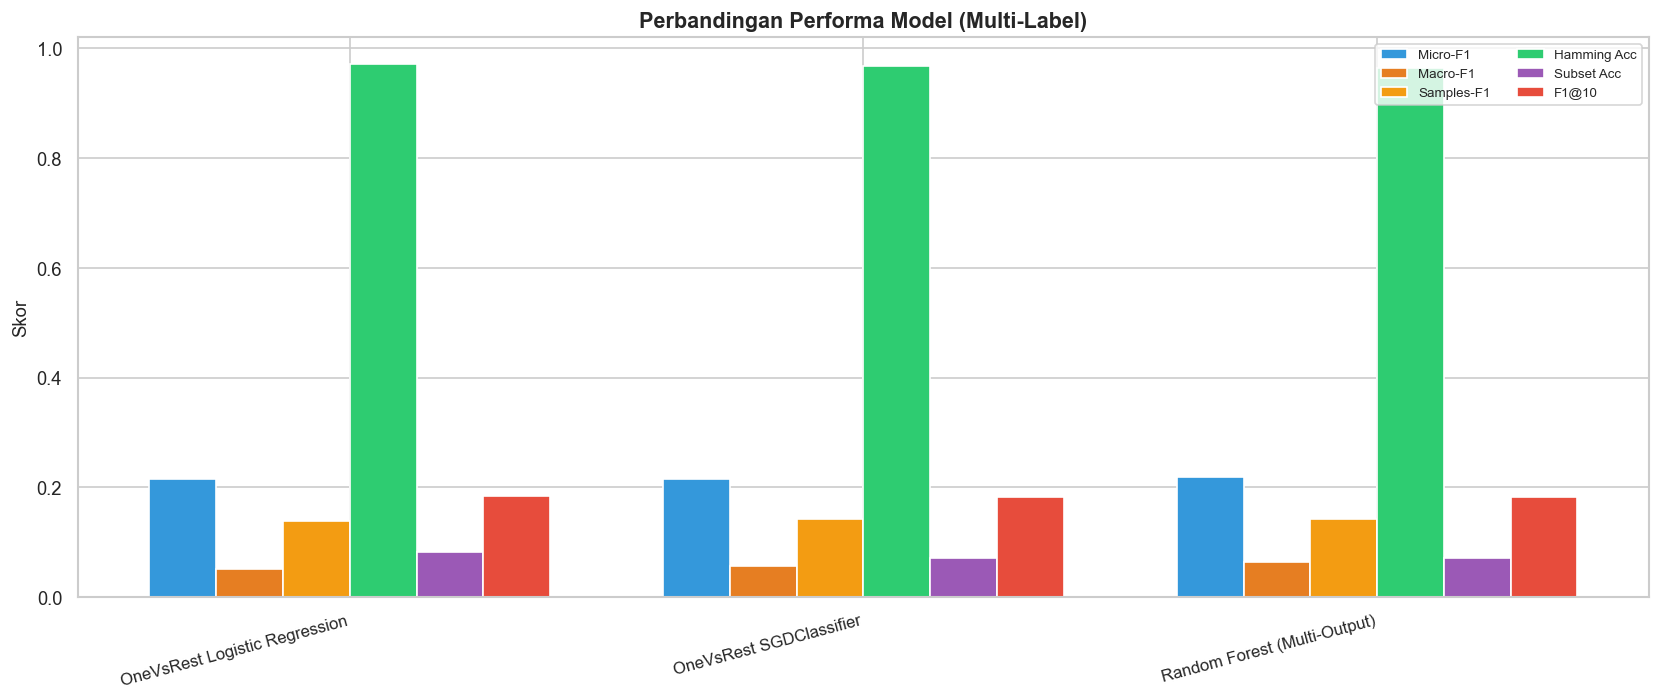

In [22]:
# === 4.2 Plot: Perbandingan Performa Model (Multi-Metric, threshold 0.1) ===
from sklearn.metrics import accuracy_score, f1_score

TH = 0.1
perf_rows = []
for name, model in models.items():
    sc = get_scores(model, X_test[bench_idx])
    yt = Y_test[bench_idx]
    yp = (sc >= TH).astype(int)
    p10 = topk_precision(yt, sc, 10)
    r10 = topk_recall(yt, sc, 10)
    f10 = 2 * p10 * r10 / (p10 + r10) if (p10 + r10) else 0.0
    perf_rows.append({
        'Model': name,
        'Micro-F1': f1_score(yt, yp, average='micro', zero_division=0),
        'Macro-F1': f1_score(yt, yp, average='macro', zero_division=0),
        'Samples-F1': f1_score(yt, yp, average='samples', zero_division=0),
        'Hamming Acc': 1 - hamming_loss(yt, yp),
        'Subset Acc': accuracy_score(yt, yp),
        'F1@10': round(f10, 4),
    })
perf_df = pd.DataFrame(perf_rows).set_index('Model')
print("PERBANDINGAN PERFORMA MODEL (threshold 0.1):")
print(perf_df.to_string())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(perf_df))
width = 0.13
metr_colors = {'Micro-F1': '#3498db', 'Macro-F1': '#e67e22', 'Samples-F1': '#f39c12',
               'Hamming Acc': '#2ecc71', 'Subset Acc': '#9b59b6', 'F1@10': '#e74c3c'}
for i, (col, colr) in enumerate(metr_colors.items()):
    ax.bar(x + (i - 2.5) * width, perf_df[col].values, width, label=col, color=colr, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(perf_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Skor', fontsize=11)
ax.set_title('Perbandingan Performa Model (Multi-Label)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('images/Perbandingan Performa Model.png', bbox_inches='tight')
plt.show()


---
### 4.3 Model Terbaik & Fungsi Prediksi Skill

Model terbaik dipilih berdasarkan **F1@10**. Fungsi `predict_skills_ml()` menjadi inti sistem: menerima **skill user + target pekerjaan**, mengembalikan **skill yang dibutuhkan** dan **rekomendasi skill yang harus dipelajari**.


In [23]:
# === 4.3 Model Terbaik + Fungsi Prediksi Skill ===
best_model_name = eval_df['F1@10'].idxmax()
best_model = models[best_model_name]
print(f"Model terbaik: {best_model_name} (F1@10 = {eval_df.loc[best_model_name, 'F1@10']:.4f})")


def predict_skills_ml(user_skills, target_job, top_n=15):
    """Prediksi skill yang dibutuhkan + rekomendasi skill yang harus dipelajari."""
    if target_job not in cat_to_idx:
        return None
    ctx = ', '.join(s.strip().lower() for s in user_skills)
    x_ctx = tfidf_ctx.transform([ctx])
    x_q = csr_matrix(onehot(cat_to_idx[target_job], N_CAT)).reshape(1, -1)
    X = hstack([x_ctx, x_q]).tocsr()
    probs = get_scores(best_model, X)[0]

    top_idx = np.argsort(-probs)[:top_n]
    required = [{'skill': candidate_skills[j], 'prob': round(float(probs[j]), 4)} for j in top_idx]

    user_norm = set(s.strip().lower() for s in user_skills)
    matched, gap = [], []
    for r in required:
        is_match = any(r['skill'] in u or u in r['skill'] for u in user_norm)
        if is_match:
            matched.append(r)
        else:
            gap.append(r)

    gap_score = len(gap) / len(required) * 100 if required else 0
    recommended = [dict(g, priority_rank=i + 1) for i, g in enumerate(gap)]

    return {
        'target_job': target_job,
        'benchmark_count': len(required),
        'required': required,
        'matched': matched,
        'gap': gap,
        'recommended': recommended,
        'gap_score': round(gap_score, 1),
        'match_score': round(100 - gap_score, 1),
    }


Model terbaik: OneVsRest Logistic Regression (F1@10 = 0.1831)


In [24]:
# === 4.3 Contoh Penggunaan ===
print("=" * 70)
print("  CONTOH PREDIKSI SKILL")
print("=" * 70)

scenarios = [
    ('Junior Developer -> Data Scientist',
     ['Python', 'SQL', 'Excel'], 'Data Scientist'),
    ('Experienced Dev -> Machine Learning',
     ['Python', 'SQL', 'Machine Learning', 'TensorFlow', 'Data Analysis', 'Statistics', 'Pandas', 'NumPy'],
     'Machine Learning'),
    ('Sysadmin -> Cloud Architect',
     ['Linux', 'Networking', 'Docker', 'Bash', 'Monitoring'], 'Cloud Architect'),
]

for desc, skills, target in scenarios:
    res = predict_skills_ml(skills, target, top_n=12)
    if not res:
        print(f"  {desc}: kategori tidak ditemukan")
        continue
    print(f"\n  {desc}")
    print(f"  Target: {res['target_job']} | Gap: {res['gap_score']}% | Match: {res['match_score']}%")
    print("   Rekomendasi (yang harus dipelajari):")
    for rec in res['recommended'][:5]:
        print(f"     {rec['priority_rank']}. {rec['skill']:28s} prob={rec['prob']:.3f}")


  CONTOH PREDIKSI SKILL

  Junior Developer -> Data Scientist
  Target: Data Scientist | Gap: 75.0% | Match: 25.0%
   Rekomendasi (yang harus dipelajari):
     1. r                            prob=0.357
     2. tableau                      prob=0.267
     3. data analysis                prob=0.232
     4. machine learning             prob=0.183
     5. data mining                  prob=0.127

  Experienced Dev -> Machine Learning
  Target: Machine Learning | Gap: 41.7% | Match: 58.3%
   Rekomendasi (yang harus dipelajari):
     1. c++                          prob=0.189
     2. deep learning                prob=0.178
     3. java                         prob=0.118
     4. artificial intelligence      prob=0.074
     5. natural language processing  prob=0.064

  Sysadmin -> Cloud Architect
  Target: Cloud Architect | Gap: 75.0% | Match: 25.0%
   Rekomendasi (yang harus dipelajari):
     1. cloud computing              prob=0.130
     2. devops                       prob=0.090
     3. ja

---
## BAB 5 — EVALUATION

Evaluasi difokuskan pada kualitas prediksi multi-label:
- **5.1** Kurva Precision/Recall/F1 @K model terbaik
- **5.2** Top-K skill yang diprediksi untuk beberapa kategori
- **5.3** Precision@10 per kategori pekerjaan
- **5.4** Evaluasi kualitatif sistem (skenario nyata)
- **5.5** Ringkasan CRISP-DM


---
### 5.1 Precision/Recall @K — Model Terbaik


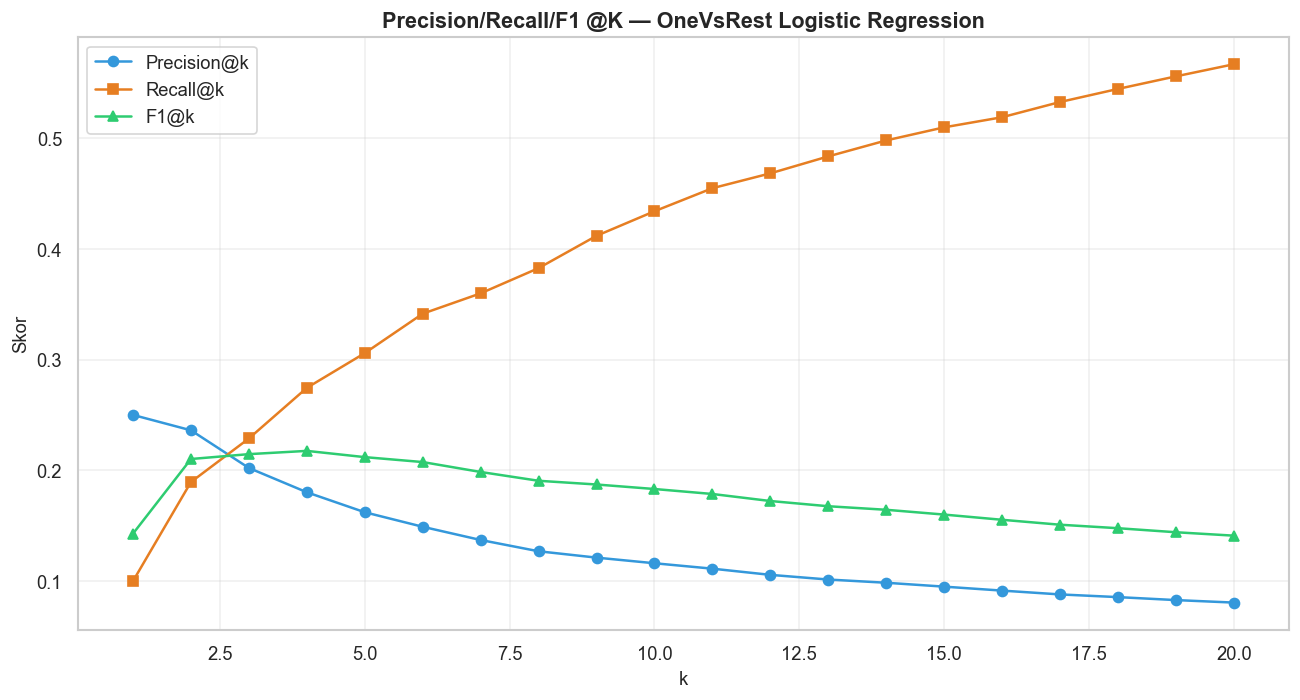

Detail @k untuk model terbaik:
 k    P@k    R@k   F1@k
 1 0.2500 0.0999 0.1428
 2 0.2361 0.1894 0.2102
 3 0.2021 0.2288 0.2146
 4 0.1801 0.2745 0.2175
 5 0.1621 0.3059 0.2119
 6 0.1490 0.3415 0.2074
 7 0.1370 0.3599 0.1985
 8 0.1268 0.3826 0.1905
 9 0.1211 0.4118 0.1872
10 0.1160 0.4340 0.1831
11 0.1111 0.4548 0.1786
12 0.1055 0.4683 0.1722
13 0.1013 0.4836 0.1675
14 0.0984 0.4980 0.1643
15 0.0949 0.5098 0.1600
16 0.0913 0.5190 0.1553
17 0.0879 0.5327 0.1508
18 0.0854 0.5445 0.1477
19 0.0827 0.5559 0.1440
20 0.0805 0.5668 0.1409


In [25]:
# === 5.1 Kurva Precision/Recall @K — Model Terbaik ===
sc = get_scores(best_model, X_test[bench_idx])
yt = Y_test[bench_idx]

k_vals = list(range(1, 21))
p_curve, r_curve, f_curve = [], [], []
for k in k_vals:
    p = topk_precision(yt, sc, k)
    r = topk_recall(yt, sc, k)
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    p_curve.append(p); r_curve.append(r); f_curve.append(f)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(k_vals, p_curve, 'o-', label='Precision@k', color='#3498db')
ax.plot(k_vals, r_curve, 's-', label='Recall@k', color='#e67e22')
ax.plot(k_vals, f_curve, '^-', label='F1@k', color='#2ecc71')
ax.set_xlabel('k', fontsize=11); ax.set_ylabel('Skor', fontsize=11)
ax.set_title(f'Precision/Recall/F1 @K — {best_model_name}', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('images/Precision Recall Kurva @K.png', bbox_inches='tight')
plt.show()

print("Detail @k untuk model terbaik:")
print(pd.DataFrame({'k': k_vals, 'P@k': np.round(p_curve, 4),
                    'R@k': np.round(r_curve, 4), 'F1@k': np.round(f_curve, 4)}).to_string(index=False))


---
### 5.2 Top-K Skill yang Diprediksi per Kategori


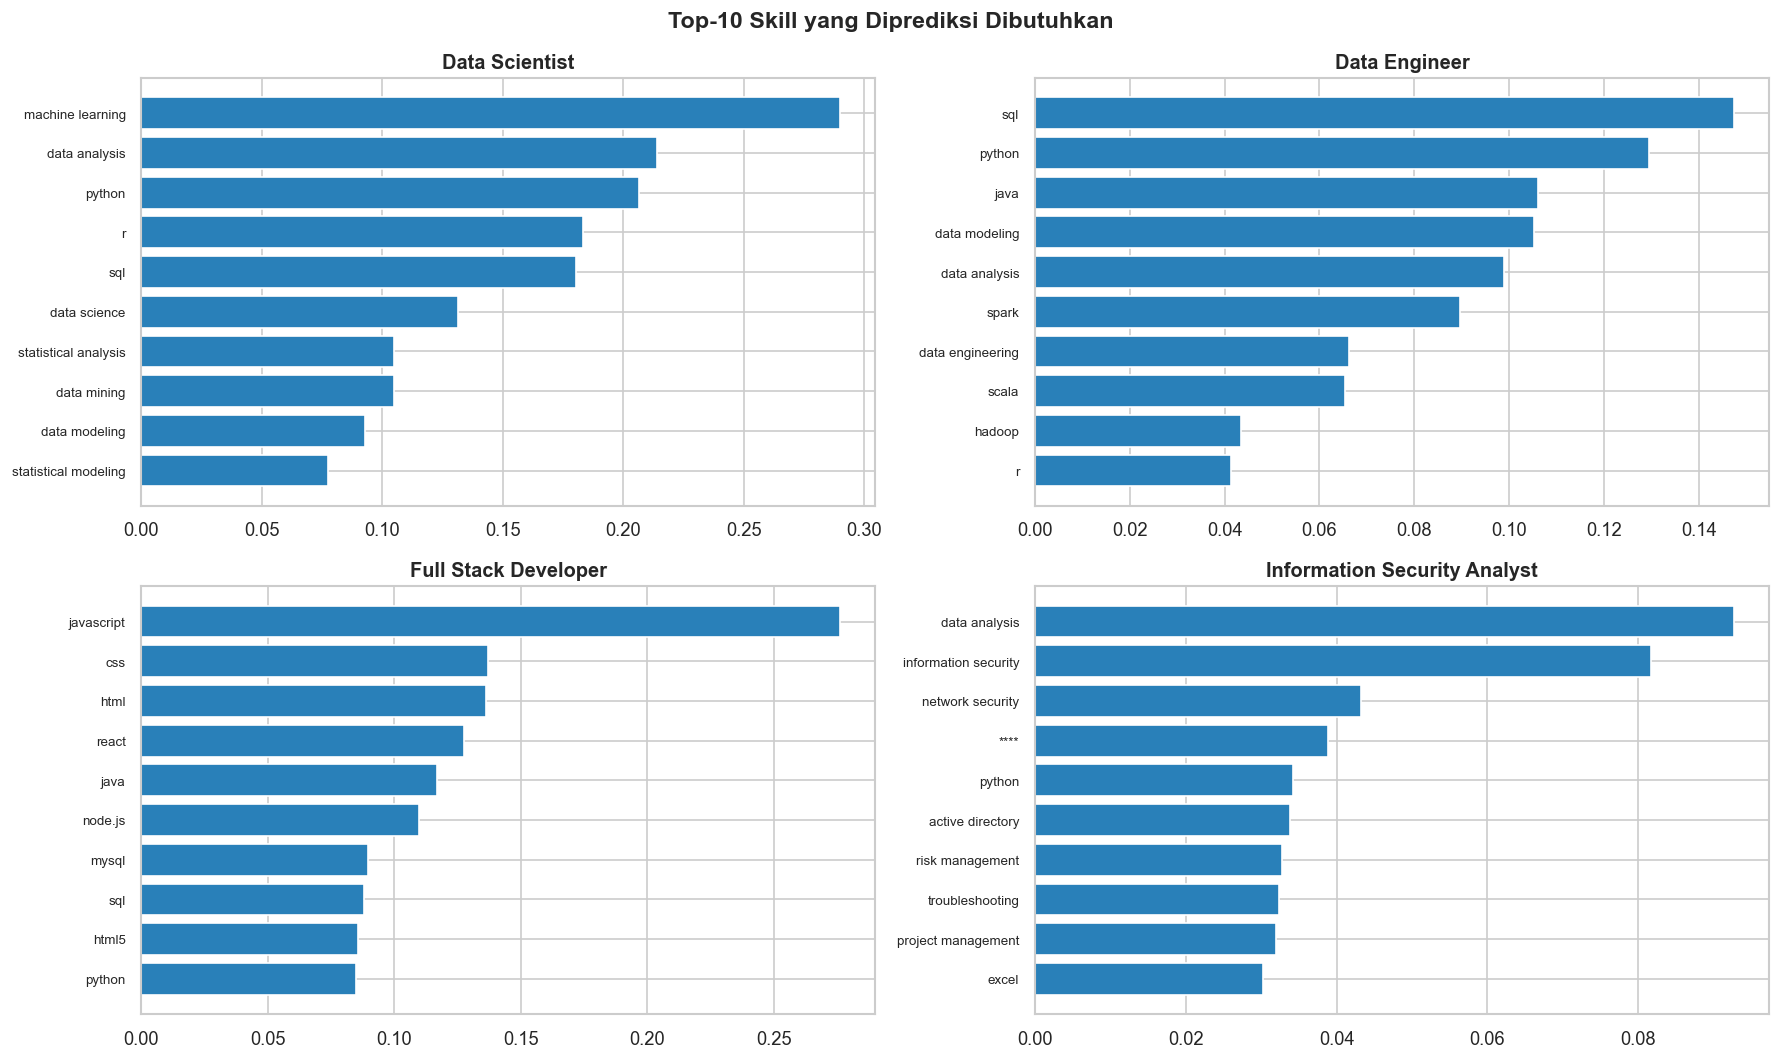

In [26]:
# === 5.2 Top-K Skill Diprediksi per Kategori ===
sample_cats = ['Data Scientist', 'Data Engineer', 'Full Stack Developer', 'Information Security Analyst']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()
for idx, cat in enumerate(sample_cats):
    res = predict_skills_ml([], cat, top_n=10)
    if not res:
        continue
    ax = axes[idx]
    skills = [r['skill'] for r in res['required']][::-1]
    probs = [r['prob'] for r in res['required']][::-1]
    ax.barh(skills, probs, color='#2980b9', edgecolor='white')
    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Top-10 Skill yang Diprediksi Dibutuhkan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/Top K Required Skills per Kategori.png', bbox_inches='tight')
plt.show()


---
### 5.3 Precision@10 per Kategori


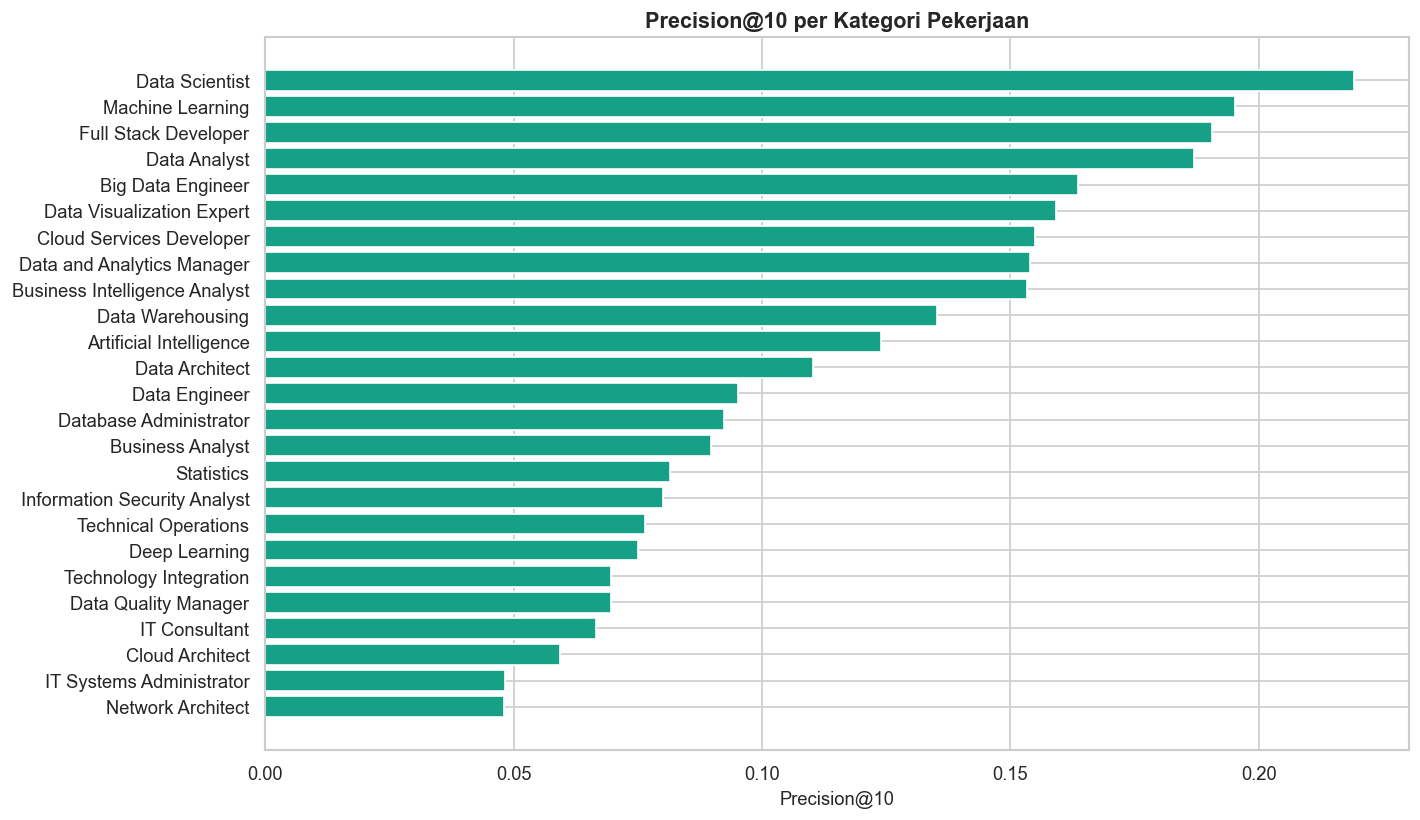

Rata-rata Precision@10 seluruh kategori: 0.1159


In [27]:
# === 5.3 Precision@10 per Kategori ===
per_cat = {}
for cat in categories_sorted:
    idxs = [i for i, c in enumerate(te_cat) if c == cat and bench_mask[i]]
    if not idxs:
        continue
    sc_c = get_scores(best_model, X_test[idxs])
    yt_c = Y_test[idxs]
    per_cat[cat] = topk_precision(yt_c, sc_c, 10)

cat_s = pd.Series(per_cat).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(cat_s.index[::-1], cat_s.values[::-1], color='#16a085', edgecolor='white')
ax.set_xlabel('Precision@10', fontsize=11)
ax.set_title('Precision@10 per Kategori Pekerjaan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/Avg Precision@10 per Kategori.png', bbox_inches='tight')
plt.show()
print(f"Rata-rata Precision@10 seluruh kategori: {cat_s.mean():.4f}")


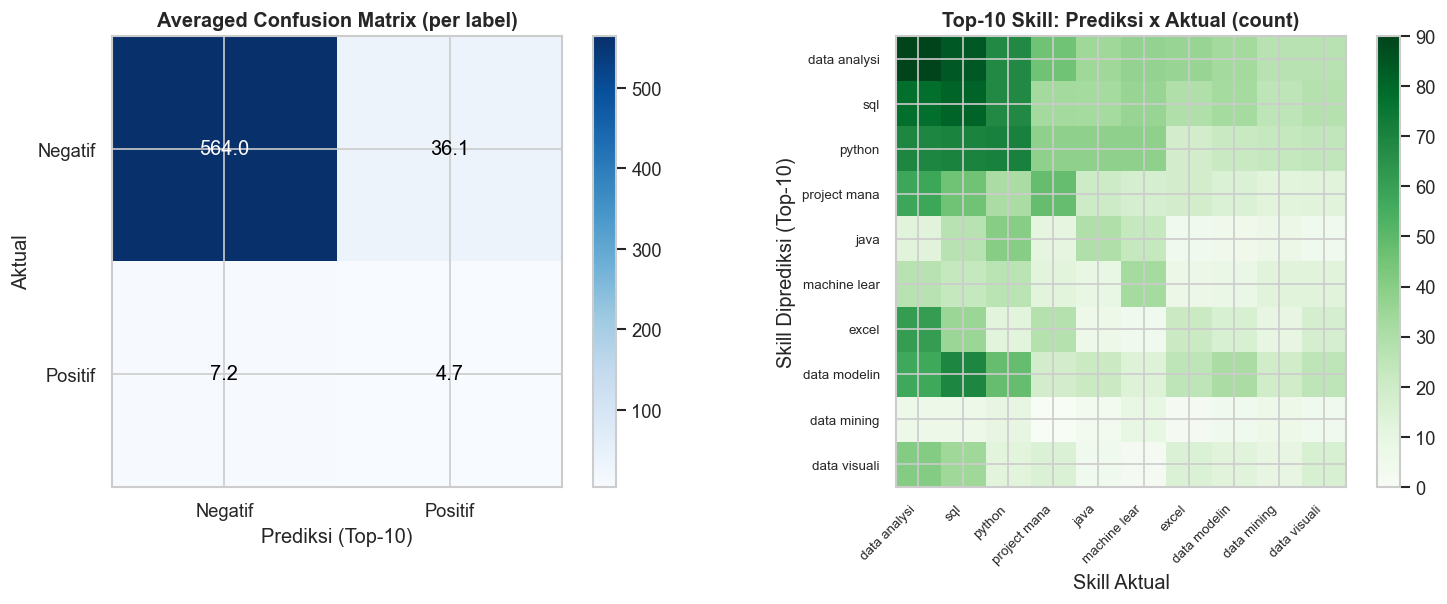

Averaged per-label (Top-10): Precision=0.1160 | Recall=0.3953 | F1=0.1794


In [28]:
# === 5.4a Confusion Matrix Multi-Label (Top-10 Predictions) ===
from sklearn.metrics import confusion_matrix

sc_best = get_scores(best_model, X_test[bench_idx])
yt_best = Y_test[bench_idx]

pred_idx = np.argsort(-sc_best, axis=1)[:, :10]
yp_best = np.zeros_like(yt_best)
for i, pidx in enumerate(pred_idx):
    yp_best[i, pidx] = 1

cm_avg = np.zeros((2, 2), dtype=float)
for l in range(yt_best.shape[1]):
    cm_avg += confusion_matrix(yt_best[:, l], yp_best[:, l], labels=[0, 1])
cm_avg = cm_avg / yt_best.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
im = ax.imshow(cm_avg, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Negatif', 'Positif']); ax.set_yticklabels(['Negatif', 'Positif'])
ax.set_xlabel('Prediksi (Top-10)'); ax.set_ylabel('Aktual')
ax.set_title('Averaged Confusion Matrix (per label)', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm_avg[i, j]:.1f}', ha='center', va='center',
                color='white' if cm_avg[i, j] > cm_avg.max() / 2 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046)

support = yt_best.sum(axis=0)
top_lab = np.argsort(-support)[:10]
cooc = yp_best[:, top_lab].T @ yt_best[:, top_lab]
ax = axes[1]
im2 = ax.imshow(cooc, cmap='Greens')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels([candidate_skills[j][:12] for j in top_lab], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([candidate_skills[j][:12] for j in top_lab], fontsize=8)
ax.set_xlabel('Skill Aktual'); ax.set_ylabel('Skill Diprediksi (Top-10)')
ax.set_title('Top-10 Skill: Prediksi x Aktual (count)', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig('images/Confusion Matrix Multi-Label.png', bbox_inches='tight')
plt.show()

tp, fp, fn = cm_avg[1, 1], cm_avg[0, 1], cm_avg[1, 0]
print(f"Averaged per-label (Top-10): Precision={tp/(tp+fp):.4f} | "
      f"Recall={tp/(tp+fn):.4f} | F1={2*tp/(2*tp+fp+fn):.4f}")


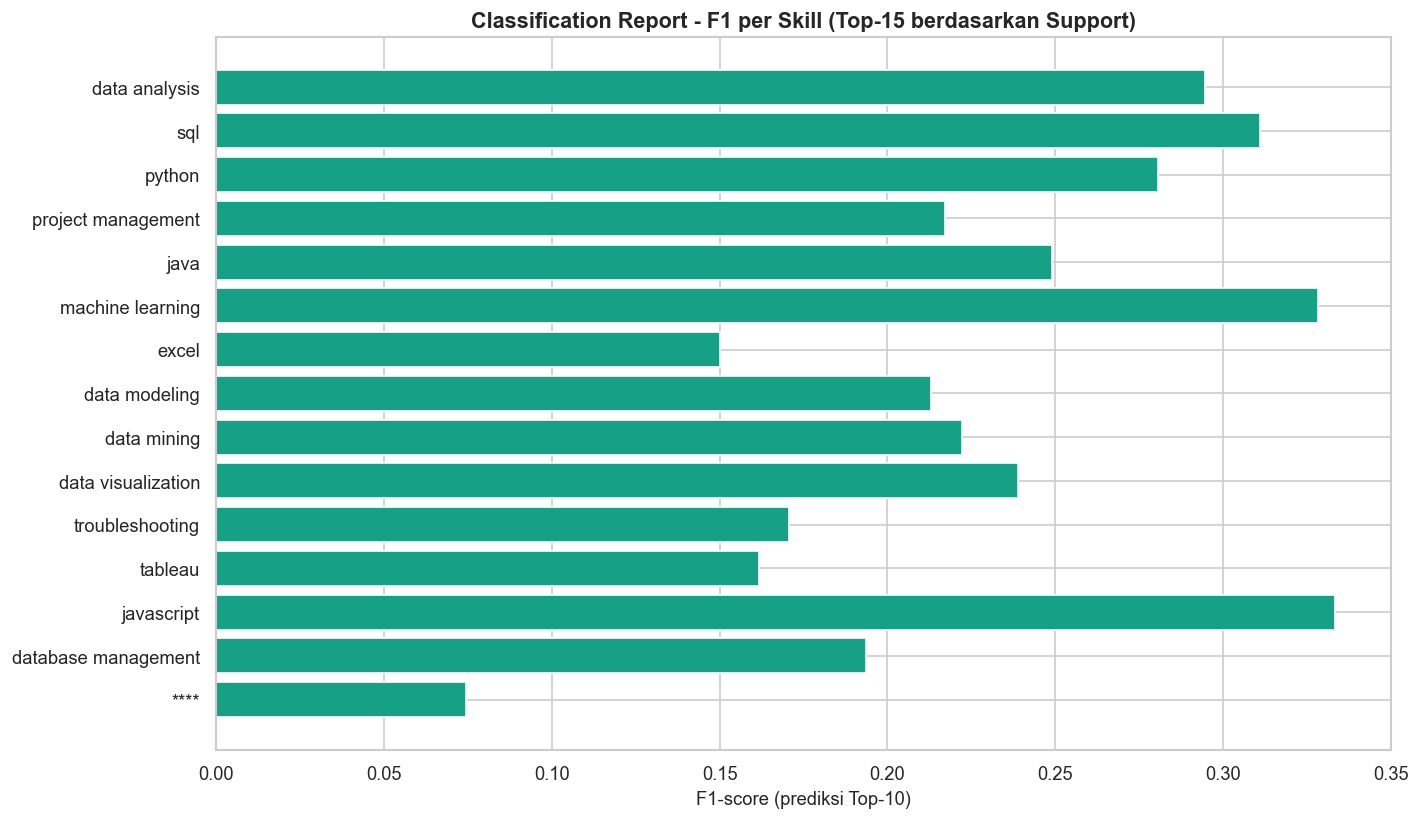

Jumlah skill dengan support > 0: 150 dari 150
              skill  precision   recall       f1  support
      data analysis   0.174419 0.947368 0.294599       95
                sql   0.187067 0.920455 0.310940       88
             python   0.165888 0.910256 0.280632       78
 project management   0.125000 0.827586 0.217195       58
               java   0.151832 0.690476 0.248927       42
   machine learning   0.207792 0.780488 0.328205       41
              excel   0.086420 0.567568 0.150000       37
      data modeling   0.120155 0.939394 0.213058       33
        data mining   0.230769 0.214286 0.222222       28
 data visualization   0.150943 0.571429 0.238806       28
    troubleshooting   0.101449 0.538462 0.170732       26
            tableau   0.108108 0.320000 0.161616       25
         javascript   0.208791 0.826087 0.333333       23
database management   0.112782 0.681818 0.193548       22
               ****   0.043165 0.272727 0.074534       22


In [29]:
# === 5.4b Classification Report per Skill (Top-10 Predictions) ===
from sklearn.metrics import classification_report

rep = classification_report(yt_best, yp_best, target_names=candidate_skills,
                            output_dict=True, zero_division=0)
rows = []
for skill in candidate_skills:
    r = rep[skill]
    if r['support'] > 0:
        rows.append({'skill': skill, 'precision': r['precision'], 'recall': r['recall'],
                     'f1': r['f1-score'], 'support': int(r['support'])})
rep_df = pd.DataFrame(rows).sort_values('support', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
top_n = rep_df.head(15)
ax.barh(top_n['skill'][::-1], top_n['f1'][::-1], color='#16a085', edgecolor='white')
ax.set_xlabel('F1-score (prediksi Top-10)', fontsize=11)
ax.set_title('Classification Report - F1 per Skill (Top-15 berdasarkan Support)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/Classification Report per Skill.png', bbox_inches='tight')
plt.show()
print(f"Jumlah skill dengan support > 0: {len(rep_df)} dari {len(candidate_skills)}")
print(rep_df.head(15).to_string(index=False))


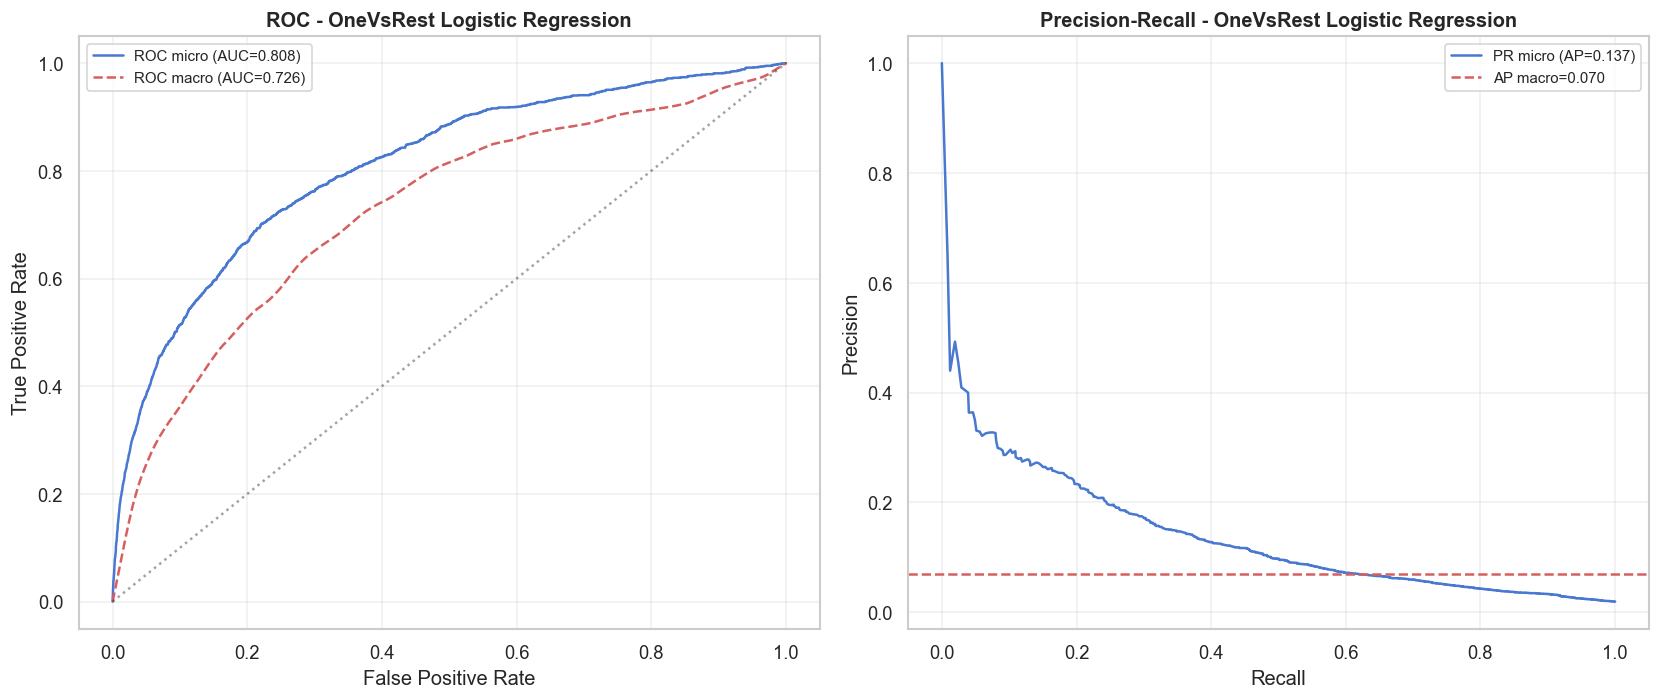

ROC AUC micro=0.8085 | macro=0.7260
PR AP micro=0.1374 | macro=0.0697


In [30]:
# === 5.4c ROC-PR Curve - Model Terbaik (Micro/Macro) ===
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

y_true_flat = yt_best.ravel()
y_score_flat = sc_best.ravel()

fpr_micro, tpr_micro, _ = roc_curve(y_true_flat, y_score_flat)
auc_micro = auc(fpr_micro, tpr_micro)

all_fpr = np.unique(np.concatenate([
    roc_curve(yt_best[:, l], sc_best[:, l])[0] for l in range(yt_best.shape[1])]))
mean_tpr = np.zeros_like(all_fpr)
for l in range(yt_best.shape[1]):
    fpr_l, tpr_l, _ = roc_curve(yt_best[:, l], sc_best[:, l])
    mean_tpr += np.interp(all_fpr, fpr_l, tpr_l)
mean_tpr /= yt_best.shape[1]
auc_macro = auc(all_fpr, mean_tpr)

prec_micro, rec_micro, _ = precision_recall_curve(y_true_flat, y_score_flat)
ap_micro = average_precision_score(y_true_flat, y_score_flat)
ap_macro = float(np.mean([average_precision_score(yt_best[:, l], sc_best[:, l])
                          for l in range(yt_best.shape[1])]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.plot(fpr_micro, tpr_micro, 'b-', label=f'ROC micro (AUC={auc_micro:.3f})')
ax.plot(all_fpr, mean_tpr, 'r--', label=f'ROC macro (AUC={auc_macro:.3f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC - {best_model_name}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(rec_micro, prec_micro, 'b-', label=f'PR micro (AP={ap_micro:.3f})')
ax.axhline(y=ap_macro, color='r', linestyle='--', label=f'AP macro={ap_macro:.3f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall - {best_model_name}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('images/ROC-PR Curve - Model Terbaik.png', bbox_inches='tight')
plt.show()
print(f"ROC AUC micro={auc_micro:.4f} | macro={auc_macro:.4f}")
print(f"PR AP micro={ap_micro:.4f} | macro={ap_macro:.4f}")


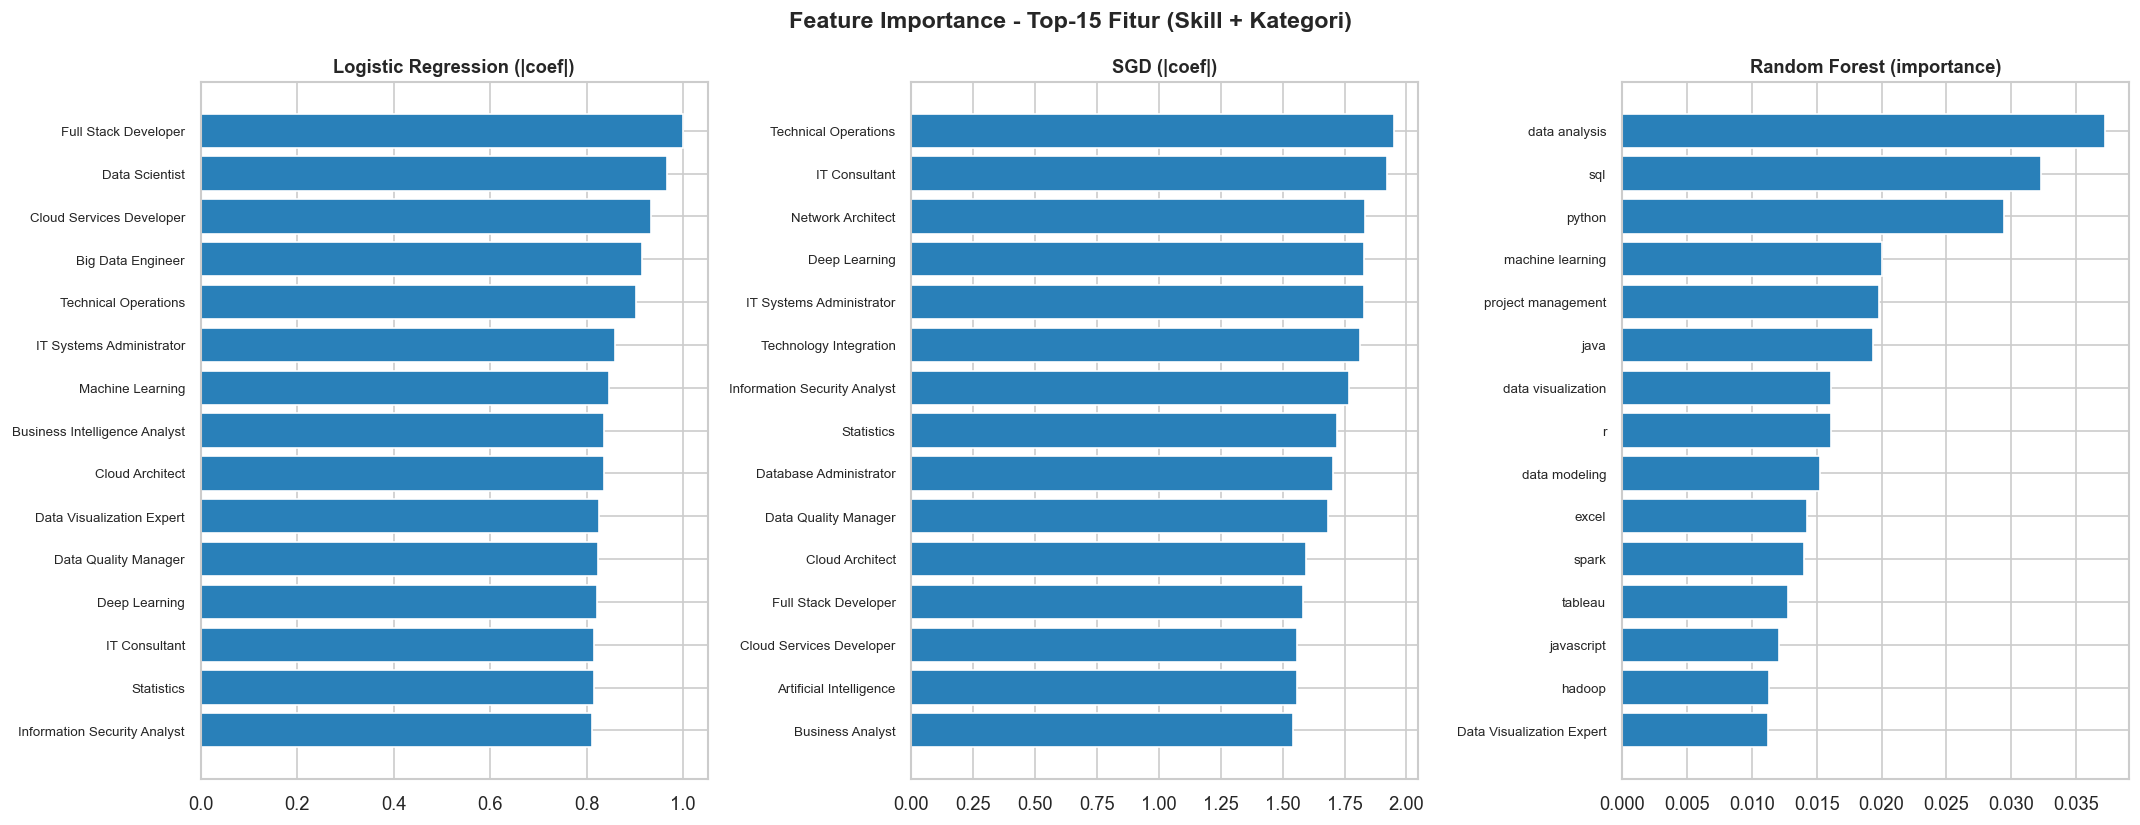

In [31]:
# === 5.4d Feature Importance - Semua Model (Top-15 Fitur) ===
feature_names = candidate_skills + categories_sorted

def top_feature_importance(feat_imp, names, k=15):
    idx = np.argsort(-feat_imp)[:k]
    return [names[i] for i in idx], [feat_imp[i] for i in idx]

lr_imp = np.mean([np.abs(e.coef_[0]) for e in models['OneVsRest Logistic Regression'].estimators_], axis=0)
sgd_imp = np.mean([np.abs(e.coef_[0]) for e in models['OneVsRest SGDClassifier'].estimators_], axis=0)
rf_imp = models['Random Forest (Multi-Output)'].feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (title, imp) in zip(axes, [
        ('Logistic Regression (|coef|)', lr_imp),
        ('SGD (|coef|)', sgd_imp),
        ('Random Forest (importance)', rf_imp)]):
    nm, vals = top_feature_importance(imp, feature_names, 15)
    ax.barh(nm[::-1], vals[::-1], color='#2980b9', edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
plt.suptitle('Feature Importance - Top-15 Fitur (Skill + Kategori)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/Feature Importance - Semua Model.png', bbox_inches='tight')
plt.show()


  Fold 1: P@10=0.2003 | F1@10=0.3106 (0.5s)
  Fold 2: P@10=0.1928 | F1@10=0.3006 (1.0s)
  Fold 3: P@10=0.2078 | F1@10=0.3196 (1.5s)
  Fold 4: P@10=0.2014 | F1@10=0.3112 (1.9s)
  Fold 5: P@10=0.1926 | F1@10=0.3001 (2.4s)
KFold 5-fold selesai (2.4s)


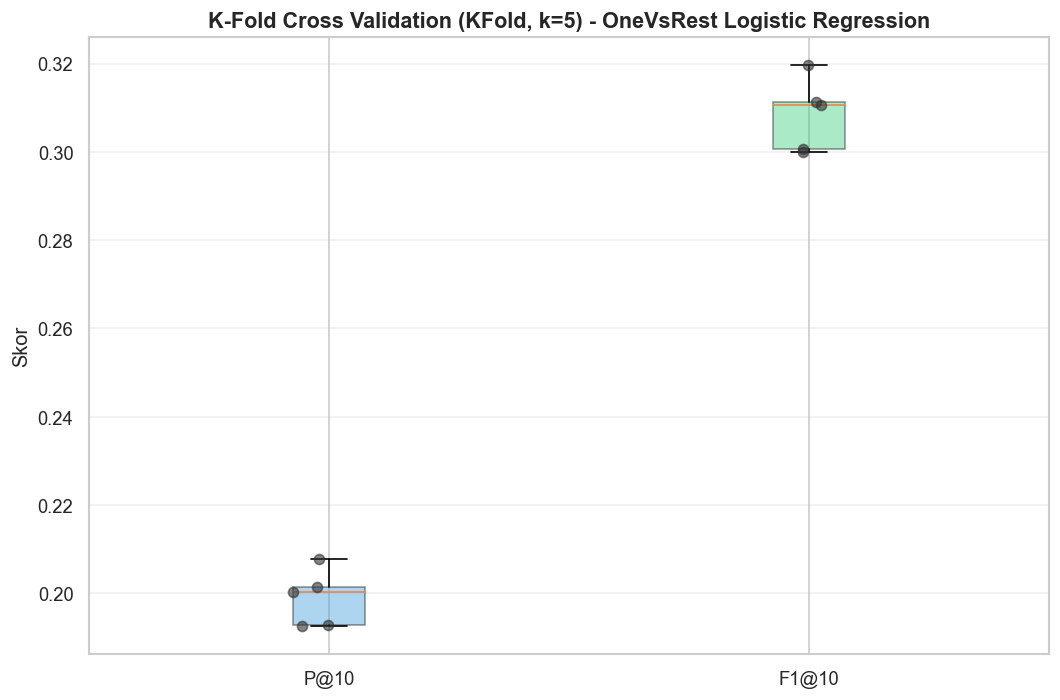

P@10  mean=0.1990 +/- 0.0057
F1@10 mean=0.3084 +/- 0.0073


In [32]:
# === 5.4e K-Fold Cross Validation (KFold, k=5) - Model Terbaik ===
from sklearn.model_selection import KFold
import time

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_p10, fold_f10 = [], []
t0 = time.time()
for fi, (tr_i, va_i) in enumerate(kf.split(X_train)):
    m_fold = OneVsRestClassifier(
        LogisticRegression(C=1.0, max_iter=2000, solver='liblinear'), n_jobs=-1)
    m_fold.fit(X_train[tr_i], Y_train[tr_i])
    scv = get_scores(m_fold, X_train[va_i])
    ytv = Y_train[va_i]
    p10 = topk_precision(ytv, scv, 10)
    r10 = topk_recall(ytv, scv, 10)
    f10 = 2 * p10 * r10 / (p10 + r10) if (p10 + r10) else 0.0
    fold_p10.append(p10); fold_f10.append(f10)
    print(f"  Fold {fi+1}: P@10={p10:.4f} | F1@10={f10:.4f} ({time.time()-t0:.1f}s)")
print(f"KFold 5-fold selesai ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(figsize=(9, 6))
data = [fold_p10, fold_f10]
bp = ax.boxplot(data, labels=['P@10', 'F1@10'], patch_artist=True)
for patch, colr in zip(bp['boxes'], ['#3498db', '#2ecc71']):
    patch.set_facecolor(colr); patch.set_alpha(0.4)
for i, vals in enumerate(data):
    ax.scatter(np.random.normal(i + 1, 0.04, len(vals)), vals, color='#333', alpha=0.6, zorder=3)
ax.set_ylabel('Skor')
ax.set_title(f'K-Fold Cross Validation (KFold, k=5) - {best_model_name}',
             fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/K-Fold Cross Validation.png', bbox_inches='tight')
plt.show()
print(f"P@10  mean={np.mean(fold_p10):.4f} +/- {np.std(fold_p10):.4f}")
print(f"F1@10 mean={np.mean(fold_f10):.4f} +/- {np.std(fold_f10):.4f}")


---
### 5.4 Evaluasi Kualitatif Sistem


In [33]:
# === 5.4 Evaluasi Kualitatif ===
print("=" * 70)
print("  EVALUASI KUALITATIF — SISTEM PREDIKSI SKILL")
print("=" * 70)

for desc, skills, target in scenarios:
    res = predict_skills_ml(skills, target, top_n=12)
    if not res:
        print(f"  {desc}: kategori tidak ditemukan")
        continue
    print(f"\n  {desc}")
    print(f"  Gap: {res['gap_score']}% | Match: {res['match_score']}%")
    print(f"   Rekomendasi top-5: {', '.join(r['skill'] for r in res['recommended'][:5])}")

covered = sum(1 for c in categories_sorted if c in cat_to_idx)
print(f"\n(c) Kategori yang didukung model: {covered}/{len(categories_sorted)}")
print(f"    Kandidat skill: {len(candidate_skills)} | Model: {best_model_name}")


  EVALUASI KUALITATIF — SISTEM PREDIKSI SKILL

  Junior Developer -> Data Scientist
  Gap: 75.0% | Match: 25.0%
   Rekomendasi top-5: r, tableau, data analysis, machine learning, data mining

  Experienced Dev -> Machine Learning
  Gap: 41.7% | Match: 58.3%
   Rekomendasi top-5: c++, deep learning, java, artificial intelligence, natural language processing

  Sysadmin -> Cloud Architect
  Gap: 75.0% | Match: 25.0%
   Rekomendasi top-5: cloud computing, devops, java, security, javascript

(c) Kategori yang didukung model: 25/25
    Kandidat skill: 150 | Model: OneVsRest Logistic Regression


---
### 5.5 Ringkasan CRISP-DM


In [34]:
# === 5.5 Ringkasan CRISP-DM ===
print("=" * 70)
print("  RINGKASAN CRISP-DM — SKILL GAP DETECTION & SKILL PREDICTION")
print("=" * 70)

best_f1 = float(eval_df.loc[best_model_name, 'F1@10'])
print(f"""
FASE CRISP-DM:
1. BUSINESS UNDERSTANDING
   - Mendeteksi gap skill antara kompetensi user dan kebutuhan industri
   - Model berperan sebagai prediktor skill yang dibutuhkan untuk suatu posisi

2. DATA UNDERSTANDING
   - {len(df_jobs):,} posting lowongan, {df_jobs['Query'].nunique()} kategori pekerjaan
   - {len(skill_counter):,} skill unik, rata-rata {df_jobs['skill_count'].mean():.1f} skill/posting

3. DATA PREPARATION
   - Normalisasi & pembersihan skill
   - {len(candidate_skills)} kandidat skill sebagai label multi-label
   - Simulasi konteks agar skill user menjadi input model
   - {X_train.shape[0]:,} instance train / {X_test.shape[0]:,} instance test

4. MODELING
   - {len(models)} arsitektur multi-label dibandingkan
   - Model terbaik: {best_model_name}

5. EVALUATION
   - F1@10 = {best_f1:.4f} pada test set (konteks kosong)
   - Precision@10 rata-rata per kategori: {cat_s.mean():.4f}

6. DEPLOYMENT
   - Artefak model disimpan ke folder final_model/
""")


  RINGKASAN CRISP-DM — SKILL GAP DETECTION & SKILL PREDICTION

FASE CRISP-DM:
1. BUSINESS UNDERSTANDING
   - Mendeteksi gap skill antara kompetensi user dan kebutuhan industri
   - Model berperan sebagai prediktor skill yang dibutuhkan untuk suatu posisi

2. DATA UNDERSTANDING
   - 3,000 posting lowongan, 25 kategori pekerjaan
   - 17,867 skill unik, rata-rata 12.1 skill/posting

3. DATA PREPARATION
   - Normalisasi & pembersihan skill
   - 150 kandidat skill sebagai label multi-label
   - Simulasi konteks agar skill user menjadi input model
   - 9,600 instance train / 2,400 instance test

4. MODELING
   - 3 arsitektur multi-label dibandingkan
   - Model terbaik: OneVsRest Logistic Regression

5. EVALUATION
   - F1@10 = 0.1831 pada test set (konteks kosong)
   - Precision@10 rata-rata per kategori: 0.1159

6. DEPLOYMENT
   - Artefak model disimpan ke folder final_model/



---
## BAB 6 — DEPLOYMENT

### 6.1 Simpan Model Multi-Label ke `final_model/`

Menyimpan model terbaik beserta objek preprocessing (TF-IDF, kandidat skill, daftar kategori) ke folder `final_model/` agar dapat dipakai oleh API.


In [35]:
import os
import json
import joblib
from datetime import datetime


def save_final_model(final_dir='final_model'):
    os.makedirs(final_dir, exist_ok=True)
    files = []

    joblib.dump(best_model, os.path.join(final_dir, 'skill_model.joblib'))
    files.append('skill_model.joblib')

    joblib.dump(tfidf_ctx, os.path.join(final_dir, 'tfidf_skills.pkl'))
    files.append('tfidf_skills.pkl')

    with open(os.path.join(final_dir, 'candidate_skills.json'), 'w', encoding='utf-8') as f:
        json.dump(candidate_skills, f, ensure_ascii=False, indent=2)
    files.append('candidate_skills.json')

    with open(os.path.join(final_dir, 'categories.json'), 'w', encoding='utf-8') as f:
        json.dump(categories_sorted, f, ensure_ascii=False, indent=2)
    files.append('categories.json')

    feature_config = {
        'n_skills': len(candidate_skills),
        'n_categories': N_CAT,
        'n_features': X_train.shape[1],
        'top_n_default': 15,
    }
    with open(os.path.join(final_dir, 'feature_config.json'), 'w') as f:
        json.dump(feature_config, f, indent=2)
    files.append('feature_config.json')

    info = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'best_model_name': best_model_name,
        'target': 'skills (multi-label)',
        'f1_at_10': best_f1,
        'n_candidate_skills': len(candidate_skills),
        'metrics': {c: float(v) for c, v in eval_df.loc[best_model_name].items()},
    }
    with open(os.path.join(final_dir, 'final_model_info.json'), 'w') as f:
        json.dump(info, f, indent=2)
    files.append('final_model_info.json')

    print('=' * 60)
    print('  MENYIMPAN MODEL MULTI-LABEL -> ' + final_dir + '/')
    print('=' * 60)
    for fn in files:
        print(f'  [OK] {fn}')


save_final_model()


  MENYIMPAN MODEL MULTI-LABEL -> final_model/
  [OK] skill_model.joblib
  [OK] tfidf_skills.pkl
  [OK] candidate_skills.json
  [OK] categories.json
  [OK] feature_config.json
  [OK] final_model_info.json
